# ZA-GAS Covariate & Long-Short Models

**Thesis chapter:** External climate drivers of precipitation tail behaviour at Belo Horizonte.

## Objective

Test whether exogenous climate variables (dew point, temperature, MJO, Niño 3.4)
improve the probabilistic forecasting of daily precipitation via the
Zero-Augmented Generalised Autoregressive Score (ZA-GAS) model.

The analysis follows the production sequence:

1. Standard GAS with $\xi_t$ time-varying + covariates
2. Standard GAS with $\phi_t$ time-varying + covariates  
3. Standard GAS with both $\phi_t, \xi_t$ time-varying + covariates
4. Long-short (L/S) decomposition for $\xi_t$
5. Long-short decomposition for $\phi_t$
6. Long-short decomposition for both $\phi_t, \xi_t$

## Mathematical Overview

### Observation model

$$p(y_t \mid \mathcal{F}_{t-1}) = (1-\pi_t)\mathbf{1}[y_t=0] + \pi_t\, g(y_t;\phi_t,\xi_t,\gamma,\zeta)\mathbf{1}[y_t>0]$$

where $g$ is the GB2 density with log-link parameters.

### Standard exogenous GAS update

For each time-varying parameter $j \in \{\phi, \xi\}$:

$$f_{j,t+1} = \omega_j + \sum_{\ell \in L} A_{j,\ell}\, s_{j,t-\ell+1} + \sum_{\ell \in L} B_{j,\ell}\, f_{j,t-\ell+1} + \Gamma_j' X_t$$

where $s_{j,t} = \mathcal{I}(f_t)^{-1} \nabla_{j,t}$ is the scaled score (Creal et al., 2012),
and $X_t$ is a vector of contemporaneous standardised covariates.

### Long-short decomposition

The time-varying parameter is decomposed into GAS, long-run, and short-run components:

$$h(\theta_t) = \omega_\theta + \underbrace{\sum_{\ell} A_\ell s_{t-\ell+1} + \sum_{\ell} B_\ell f_{t-\ell+1}}_{\text{GAS}^\theta_t} + \underbrace{L^\theta_t}_{\text{long}} + \underbrace{S^\theta_t}_{\text{short}}$$

with
$$L^\theta_t = \alpha^\theta_L L^\theta_{t-1} + (\beta^\theta_L)' X^{\text{long}}_t, \qquad S^\theta_t = (\Gamma^\theta_S)' X^{\text{short}}_t$$

**Interpretation:** $L_t$ captures low-frequency ENSO/Niño 3.4 forcing;
$S_t$ captures short-run local weather (dew point, temperature, MJO).

### References

- Creal, Koopman & Lucas (2012). *Generalized autoregressive score models.* JAE 28(5).
- Gneiting & Raftery (2007). *Strictly proper scoring rules.* JASA 102.
- Gneiting & Ranjan (2011). *Threshold- and quantile-weighted scoring rules.* JBES 29.
- Kupiec (1995). *Techniques for verifying risk measurement models.* J. Derivatives 3.
- Christoffersen (1998). *Evaluating interval forecasts.* IER 39.
- Hersbach et al. (2020). *The ERA5 global reanalysis.* QJRMS 146.
- Wheeler & Hendon (2004). *An all-season real-time multivariate MJO index.* MWR 132.
- NOAA/PSL for daily Niño 3.4 index data.

---
## Configuration

Edit **only** this cell to control the full analysis.

In [1]:
from pathlib import Path

# ── Station ───────────────────────────────────────────────────────────────────
STATION      = "BELO HORIZONTE"   # precipitation filename prefix (has space)
ERA5_STATION = "BELO_HORIZONTE"   # ERA5 filename prefix (has underscore)

# ── Output paths (PROJECT_ROOT first) ─────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve()
CACHE_DIR    = PROJECT_ROOT / "artifacts" / "cache_covariates_long_short"
REPORT_DIR   = PROJECT_ROOT / "artifacts" / "reports" / "covariates_long_short"

# ── Precipitation data paths ──────────────────────────────────────────────────
DATA_ROOT  = Path(r"C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\data")
PREC_TRAIN = DATA_ROOT / "output" / f"{STATION}_train.csv"
PREC_TEST  = DATA_ROOT / "output" / f"{STATION}_test.csv"

# ── Covariate data paths ──────────────────────────────────────────────────────
ERA5_DEW_DIR  = PROJECT_ROOT / "data" / "input" / "ERA5" / "humidity"      # dewpoint CSVs
ERA5_TEMP_DIR = PROJECT_ROOT / "data" / "input" / "ERA5" / "temperature"   # temperature CSVs
MJO_PATH      = PROJECT_ROOT / "data" / "input" / "pacific" / "MJO.csv"
NINO34_PATH   = PROJECT_ROOT / "data" / "processed" / "pacific" / "NINO34_daily.csv"

# Column names in covariate files
ERA5_DATE_COL   = "date"
MJO_DATE_COL    = "date"
MJO_RMM1_COL    = "RMM1"
MJO_RMM2_COL    = "RMM2"
NINO34_DATE_COL = "date"
NINO34_VAL_COL  = "nino34_sst"   # column in NINO34_daily.csv

# ── Precipitation column names ────────────────────────────────────────────────
Y_COL    = "PRECIPITACAO TOTAL, DIARIO(mm)"
DATE_COL = "Data Medicao"

# ── Model scope flags ─────────────────────────────────────────────────────────
RUN_XI        = True
RUN_PHI       = True
RUN_PHI_XI    = True
RUN_LS_XI     = True
RUN_LS_PHI    = True
RUN_LS_PHI_XI = True

# ── Refit control ─────────────────────────────────────────────────────────────
FORCE_REFIT = False

# ── Seasonal setting ──────────────────────────────────────────────────────────
SEASONAL = "daily"

# ── Optimiser settings ────────────────────────────────────────────────────────
OPT_OPTIONS = {"maxiter": 1000, "gtol": 1e-4}

# ── Monte Carlo draws for CRPS ────────────────────────────────────────────────
N_MC_DRAWS = 500
MC_SEED    = 42

# ── Inference: compute numerical Hessian? ─────────────────────────────────────
COMPUTE_NUMERICAL_HESSIAN = False  # set True later for selected models only

print(f"Configuration loaded.")
print(f"  PREC_TRAIN  : {PREC_TRAIN}")
print(f"  ERA5_DEW_DIR: {ERA5_DEW_DIR}")
print(f"  ERA5_TEMP_DIR:{ERA5_TEMP_DIR}")
print(f"  MJO_PATH    : {MJO_PATH}")
print(f"  NINO34_PATH : {NINO34_PATH}")
print(f"  FORCE_REFIT : {FORCE_REFIT}")




Configuration loaded.
  PREC_TRAIN  : C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\data\output\BELO HORIZONTE_train.csv
  ERA5_DEW_DIR: C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\data\input\ERA5\humidity
  ERA5_TEMP_DIR:C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\data\input\ERA5\temperature
  MJO_PATH    : C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\data\input\pacific\MJO.csv
  NINO34_PATH : C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\data\processed\pacific\NINO34_daily.csv
  FORCE_REFIT : False


---
## Imports

In [2]:
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 9})

# ── Project modules ───────────────────────────────────────────────────────────
from distributions import GB2LogLink, GB2LogLinkPhiOnly, GB2LogLinkXiOnly
from pi_dynamics.ar_logistic import ARLogisticPiDynamics
from models.cov_gas_model  import CovZAGASModel
from models.long_short_gas import LongShortZAGASModel
from models.inference      import compute_inference
from covariates.builder    import (
    load_era5_dew_point, load_era5_temperature,
    load_mjo, load_nino34,
    build_covariate_blocks, align_covariates, df_to_array,
)
from covariates.standardizer import CovariateStandardizer
from diagnostics.residuals   import pit_values, quantile_residuals
from diagnostics.tests       import kupiec_test, christoffersen_test
from diagnostics.scoring     import compute_all_metrics, metrics_to_frame
from report.cov_report       import render_covariate_report

warnings.filterwarnings("ignore", category=RuntimeWarning)
print("Imports OK")

Imports OK


---
## Data Loading

In [3]:
# ── Precipitation ─────────────────────────────────────────────────────────────
def _load_prec(path, y_col=Y_COL, date_col=DATE_COL):
    df = pd.read_csv(path, parse_dates=[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    y  = df[y_col].to_numpy(dtype=float)
    dates = pd.DatetimeIndex(df[date_col])
    return y, dates

y_train, train_dates = _load_prec(PREC_TRAIN)
y_test,  test_dates  = _load_prec(PREC_TEST)

print(f"Train: {len(y_train):,} days  ({train_dates[0].date()} – {train_dates[-1].date()})")
print(f"Test:  {len(y_test):,} days  ({test_dates[0].date()}  – {test_dates[-1].date()})")
print(f"Zero fraction (train): {(y_train == 0).mean():.3f}")
print(f"Zero fraction (test):  {(y_test  == 0).mean():.3f}")

Train: 3,652 days  (2014-01-01 – 2023-12-31)
Test:  731 days  (2024-01-01  – 2025-12-31)
Zero fraction (train): 0.723
Zero fraction (test):  0.706


---
## Covariate Construction

All covariates are:
1. Loaded and aligned to the train+test date range.
2. Lag-expanded according to the modelling protocol.
3. **Standardised using training-set moments only** — no leakage.

In [4]:
all_dates = train_dates.append(test_dates)  # full date range

# ── Load raw covariates (None if file missing) ────────────────────────────────
def _try_load(fn, *args, **kwargs):
    try:
        return fn(*args, **kwargs)
    except Exception as e:
        print(f"  Skipping: {e}")
        return None

print("Loading covariates...")
dew_raw  = _try_load(load_era5_dew_point,  ERA5_DEW_DIR,  all_dates,
                     date_col=ERA5_DATE_COL, station=ERA5_STATION)
temp_raw = _try_load(load_era5_temperature, ERA5_TEMP_DIR, all_dates,
                     date_col=ERA5_DATE_COL, station=ERA5_STATION)
mjo_raw  = _try_load(load_mjo,  MJO_PATH, all_dates,
                     date_col=MJO_DATE_COL, rmm1_col=MJO_RMM1_COL, rmm2_col=MJO_RMM2_COL)
n34_raw  = _try_load(load_nino34, NINO34_PATH, all_dates,
                     date_col=NINO34_DATE_COL, value_col=NINO34_VAL_COL)

print(f"  Dew point:   {'OK' if dew_raw  is not None else 'MISSING'}")
print(f"  Temperature: {'OK' if temp_raw is not None else 'MISSING'}")
print(f"  MJO:         {'OK' if mjo_raw  is not None else 'MISSING'}")
print(f"  Nino 3.4:    {'OK' if n34_raw  is not None else 'MISSING'}")



Loading covariates...
  Dew point:   OK
  Temperature: OK
  MJO:         OK
  Nino 3.4:    OK


In [5]:
# ── Build all lag blocks (unstandardised) ─────────────────────────────────────
raw_blocks = build_covariate_blocks(
    dewpoint    = dew_raw,
    temperature = temp_raw,
    mjo         = mjo_raw,
    nino34      = n34_raw,
)

# Align all blocks to the full date range
raw_blocks = align_covariates(raw_blocks, all_dates, fill_value=np.nan)

print(f"Built {len(raw_blocks)} covariate blocks:")
for name, df in raw_blocks.items():
    print(f"  {name:45s}  shape={df.shape}")

Built 22 covariate blocks:
  dewpoint_t                                     shape=(4383, 1)
  dewpoint_lag1                                  shape=(4383, 2)
  dewpoint_short_lags                            shape=(4383, 4)
  dewpoint_seasonal_lags                         shape=(4383, 8)
  temperature_t                                  shape=(4383, 1)
  temperature_lag1                               shape=(4383, 2)
  temperature_short_lags                         shape=(4383, 4)
  temperature_seasonal_lags                      shape=(4383, 8)
  dewpoint_temperature_t                         shape=(4383, 2)
  dewpoint_temperature_lag1                      shape=(4383, 4)
  dewpoint_temperature_short_lags                shape=(4383, 8)
  dewpoint_temperature_seasonal_lags             shape=(4383, 16)
  mjo_t                                          shape=(4383, 2)
  mjo_lag1                                       shape=(4383, 4)
  mjo_short_lags                                 shape=(4383, 

In [6]:
# ── Standardise: fit on TRAIN portion, apply to ALL ───────────────────────────
n_train = len(y_train)

std_blocks = {}   # {block_name: pd.DataFrame (standardised, full length)}
scaler_by_block = {}  # {block_name: CovariateStandardizer}

for bname, df_full in raw_blocks.items():
    df_train_part = df_full.iloc[:n_train]
    scaler = CovariateStandardizer(columns=list(df_full.columns))
    scaler.fit(df_train_part)
    std_blocks[bname]   = scaler.transform(df_full)
    scaler_by_block[bname] = scaler

print("Standardisation complete. Training moments used (no leakage).")

# Save standardiser parameters
CACHE_DIR.mkdir(parents=True, exist_ok=True)
(CACHE_DIR / "scalers").mkdir(exist_ok=True)
for bname, sc in scaler_by_block.items():
    sc.save(CACHE_DIR / "scalers" / f"{bname}.json")

Standardisation complete. Training moments used (no leakage).


---
## Covariate Descriptive Statistics

Computed on the **training portion only** (no leakage). Includes:
count, mean, std, min/max, quantiles (5/25/50/75/95), skewness, kurtosis,
lag-1 and lag-365 autocorrelation, monthly seasonality heatmaps,
ACF grids, and per-covariate 6-panel diagnostic figures.

All tables are saved as LaTeX files and included in the report.


In [7]:
from diagnostics.covariate_stats import (
    compute_all_covariate_stats,
    latex_summary_table, latex_seasonality_table, plot_covariate_page,
)

covariate_stats = compute_all_covariate_stats(
    raw_blocks  = raw_blocks,
    std_blocks  = std_blocks,
    train_dates = train_dates,
    all_dates   = all_dates,
)
raw_sum = covariate_stats["raw_summary"]
std_sum = covariate_stats["std_summary"]
print(f"Unique covariates tracked: {len(raw_sum)}")


Unique covariates tracked: 34


In [8]:
# ── Display summary tables ───────────────────────────────────────────────────
show_cols = [c for c in ["mean","std","min","q05","q25","q50",
                           "q75","q95","max","skew","kurt","acf_1","acf_365"]
             if c in raw_sum.columns]
print("Raw covariate summary (training set):")
display(raw_sum[show_cols].round(4))
print("\nNormalised covariate summary (training set):")
display(std_sum[show_cols].round(4))


Raw covariate summary (training set):


,mean,std,min,q05,q25,q50,q75,q95,max,skew,kurt,acf_1,acf_365
variable,,,,,,,,,,,,,
dewpoint_t,14.9324,3.2163,2.0197,9.2692,12.5276,15.5876,17.6309,19.1628,20.5317,-0.5342,-0.4912,0.9264,0.6421
dewpoint_lag1,14.9313,3.2161,2.0197,9.2691,12.5276,15.5855,17.6305,19.1628,20.5317,-0.5339,-0.4912,0.9264,0.6420
dewpoint_lag2,14.9298,3.2152,2.0197,9.2691,12.5276,15.5825,17.6292,19.1612,20.5317,-0.5345,-0.4912,0.9264,0.6418
dewpoint_lag3,14.9285,3.2147,2.0197,9.2691,12.5276,15.5795,17.6257,19.1590,20.5317,-0.5346,-0.4911,0.9263,0.6417
dewpoint_lag364,14.9001,3.2240,2.0197,9.2698,12.4810,15.5541,17.5824,19.1797,20.5317,-0.5272,-0.4779,0.9256,0.6404
dewpoint_lag365,14.8993,3.2241,2.0197,9.2698,12.4809,15.5534,17.5802,19.1799,20.5317,-0.5267,-0.4783,0.9256,0.6403
dewpoint_lag366,14.8983,3.2241,2.0197,9.2697,12.4809,15.5490,17.5786,19.1801,20.5317,-0.5262,-0.4785,0.9256,0.6402
dewpoint_lag367,14.8972,3.2240,2.0197,9.2697,12.4808,15.5445,17.5785,19.1803,20.5317,-0.5258,-0.4785,0.9256,0.6401
temperature_t,20.7977,2.6567,10.4927,16.1865,18.9341,21.1219,22.7702,24.6126,28.6729,-0.3289,-0.3143,0.9221,0.6142



Normalised covariate summary (training set):


,mean,std,min,q05,q25,q50,q75,q95,max,skew,kurt,acf_1,acf_365
variable,,,,,,,,,,,,,
dewpoint_t,-0.0,1.0,-4.0147,-1.7608,-0.7477,0.2037,0.8390,1.3153,1.7409,-0.5342,-0.4912,0.9264,0.6421
dewpoint_lag1,-0.0,1.0,-4.0147,-1.7606,-0.7474,0.2034,0.8393,1.3157,1.7414,-0.5339,-0.4912,0.9264,0.6420
dewpoint_lag2,-0.0,1.0,-4.0153,-1.7606,-0.7471,0.2030,0.8396,1.3161,1.7423,-0.5345,-0.4912,0.9264,0.6418
dewpoint_lag3,-0.0,1.0,-4.0155,-1.7605,-0.7469,0.2025,0.8390,1.3160,1.7430,-0.5346,-0.4911,0.9263,0.6417
dewpoint_lag364,0.0,1.0,-3.9952,-1.7464,-0.7503,0.2029,0.8320,1.3274,1.7468,-0.5272,-0.4779,0.9256,0.6404
dewpoint_lag365,0.0,1.0,-3.9947,-1.7461,-0.7501,0.2029,0.8315,1.3277,1.7470,-0.5267,-0.4783,0.9256,0.6403
dewpoint_lag366,0.0,1.0,-3.9944,-1.7458,-0.7498,0.2018,0.8313,1.3280,1.7473,-0.5262,-0.4785,0.9256,0.6402
dewpoint_lag367,0.0,1.0,-3.9942,-1.7455,-0.7495,0.2008,0.8317,1.3285,1.7477,-0.5258,-0.4785,0.9256,0.6401
temperature_t,0.0,1.0,-3.8789,-1.7357,-0.7015,0.1220,0.7425,1.4359,2.9643,-0.3289,-0.3143,0.9221,0.6142


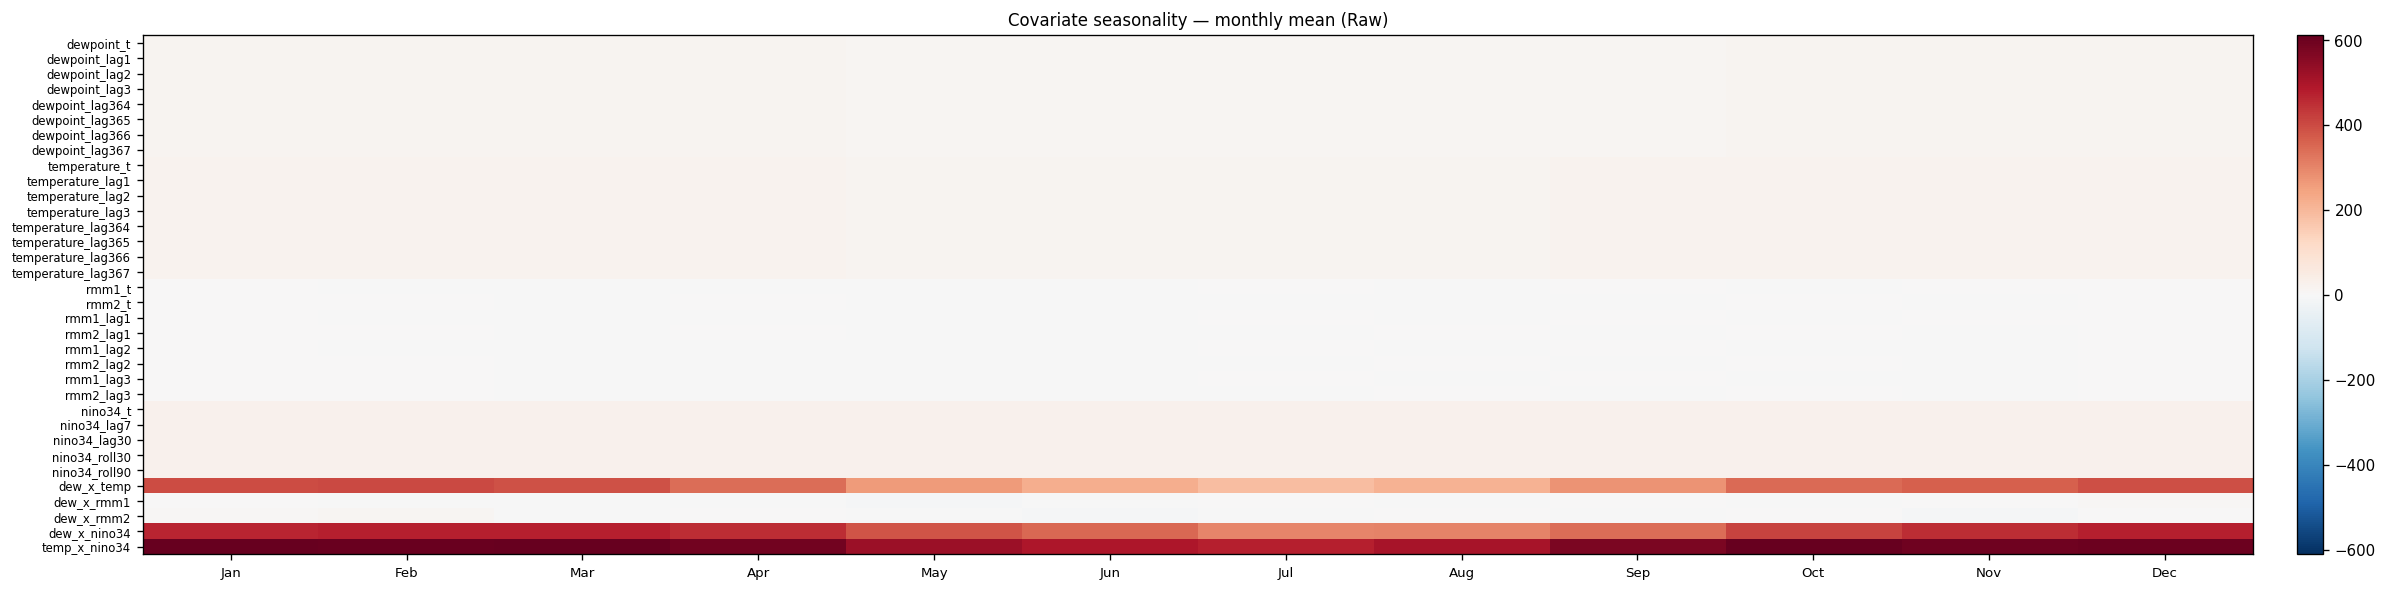

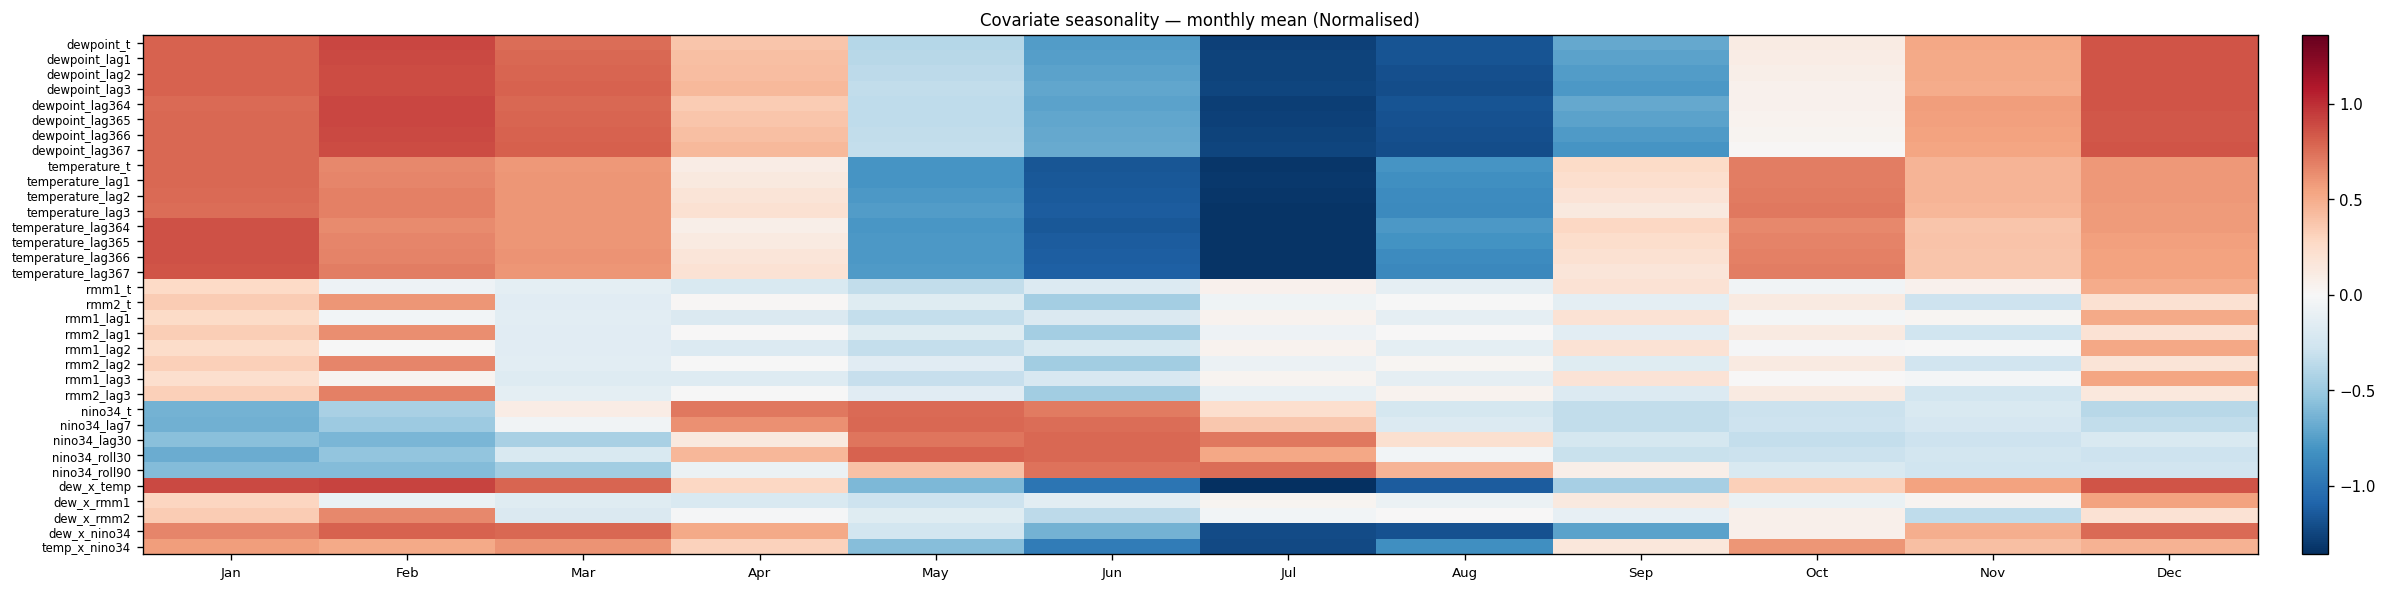

Covariate stats tables saved.


In [9]:
# ── Seasonality heatmap (raw) ────────────────────────────────────────────────
seas_raw = covariate_stats["seasonality_raw"]
seas_std = covariate_stats["seasonality_std"]
REPORT_DIR.mkdir(parents=True, exist_ok=True)

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
for _label, _seas in [("Raw", seas_raw), ("Normalised", seas_std)]:
    if _seas is None or _seas.empty:
        continue
    _mat = _seas.values.astype(float)
    _vext = np.nanmax(np.abs(_mat)) if np.any(np.isfinite(_mat)) else 1.0
    fig, ax = plt.subplots(figsize=(min(20, max(8, _seas.shape[1]*0.7+2)), 5))
    im = ax.imshow(_mat.T, cmap="RdBu_r", vmin=-_vext, vmax=_vext, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    ax.set_xticks(range(12))
    ax.set_xticklabels(month_names, fontsize=8)
    ax.set_yticks(range(_seas.shape[1]))
    ax.set_yticklabels([c[:22] for c in _seas.columns], fontsize=7)
    ax.set_title(f"Covariate seasonality — monthly mean ({_label})", fontsize=10)
    plt.tight_layout()
    fig.savefig(REPORT_DIR / f"cov_seasonality_{_label.lower()}.png",
                dpi=110, bbox_inches="tight")
    plt.show()

# Save LaTeX
REPORT_DIR.mkdir(parents=True, exist_ok=True)
(REPORT_DIR / "cov_summary_raw.tex").write_text(
    latex_summary_table(raw_sum, "Covariate summary (raw)", "tab:cov_sum_raw"),
    encoding="utf-8")
(REPORT_DIR / "cov_summary_std.tex").write_text(
    latex_summary_table(std_sum, "Covariate summary (normalised)", "tab:cov_sum_std"),
    encoding="utf-8")
if not seas_raw.empty:
    (REPORT_DIR / "cov_seasonality_raw.tex").write_text(
        latex_seasonality_table(seas_raw, "Monthly means (raw)", "tab:cov_seas_raw"),
        encoding="utf-8")
if not seas_std.empty:
    (REPORT_DIR / "cov_seasonality_std.tex").write_text(
        latex_seasonality_table(seas_std, "Monthly means (normalised)", "tab:cov_seas_std"),
        encoding="utf-8")
print("Covariate stats tables saved.")


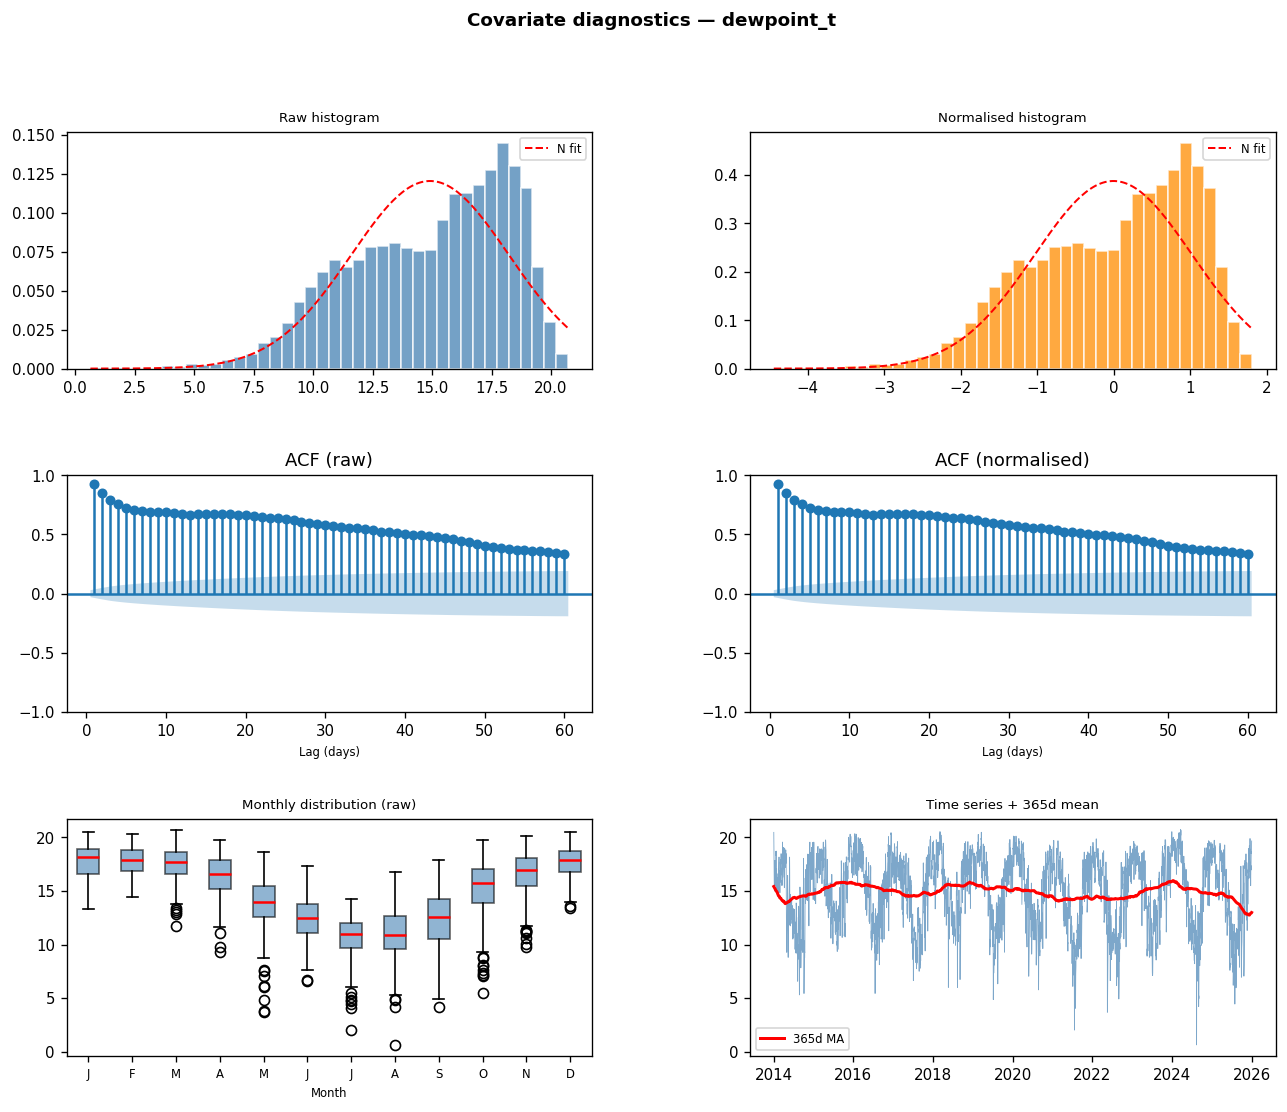

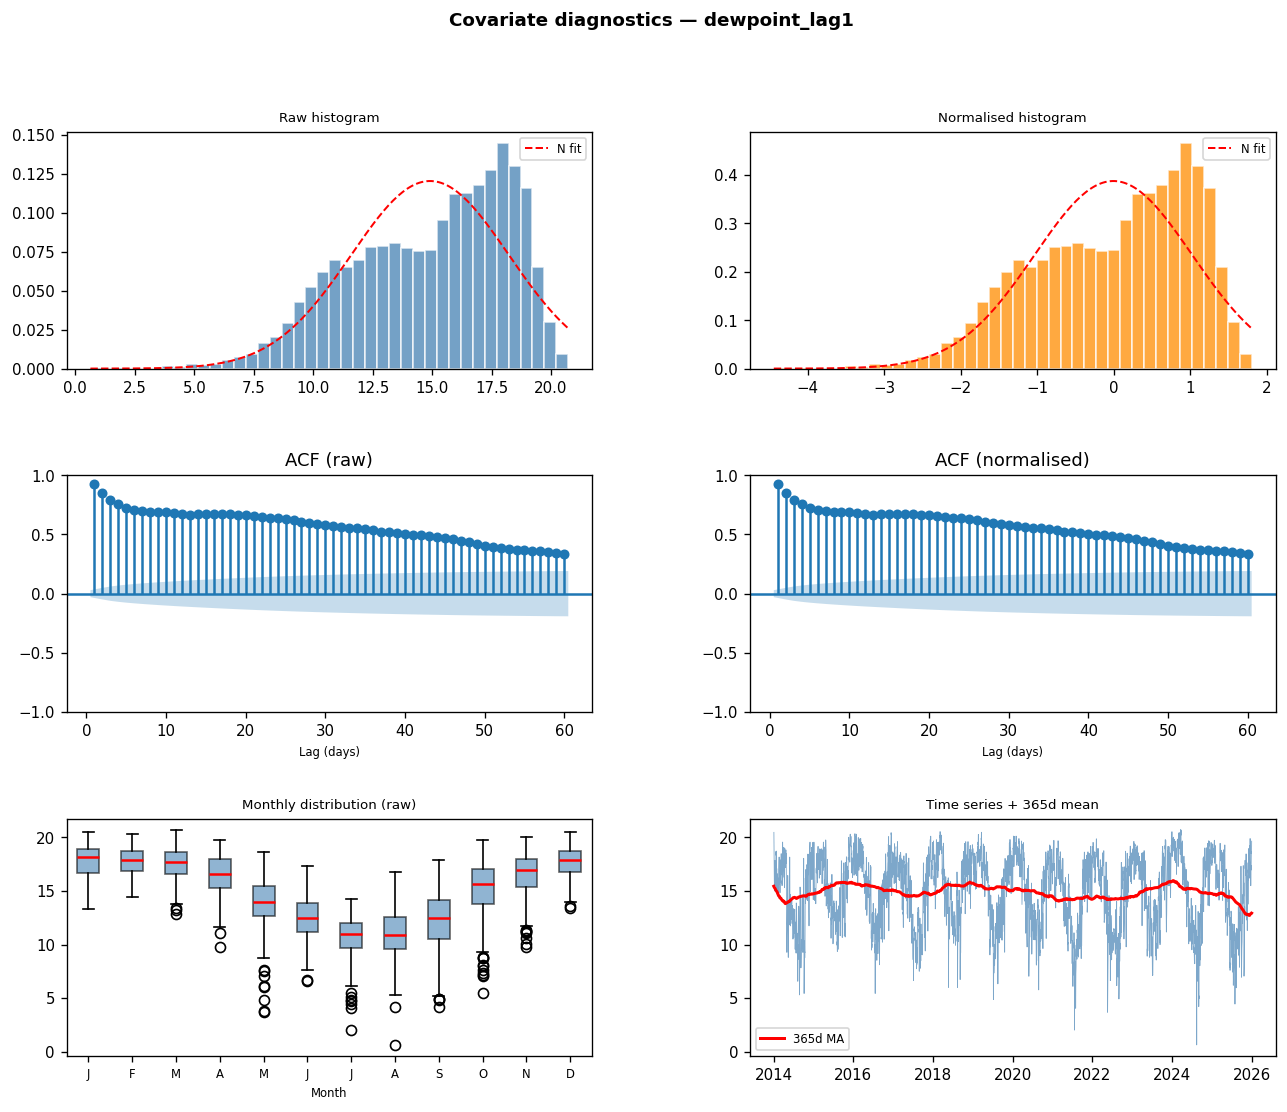

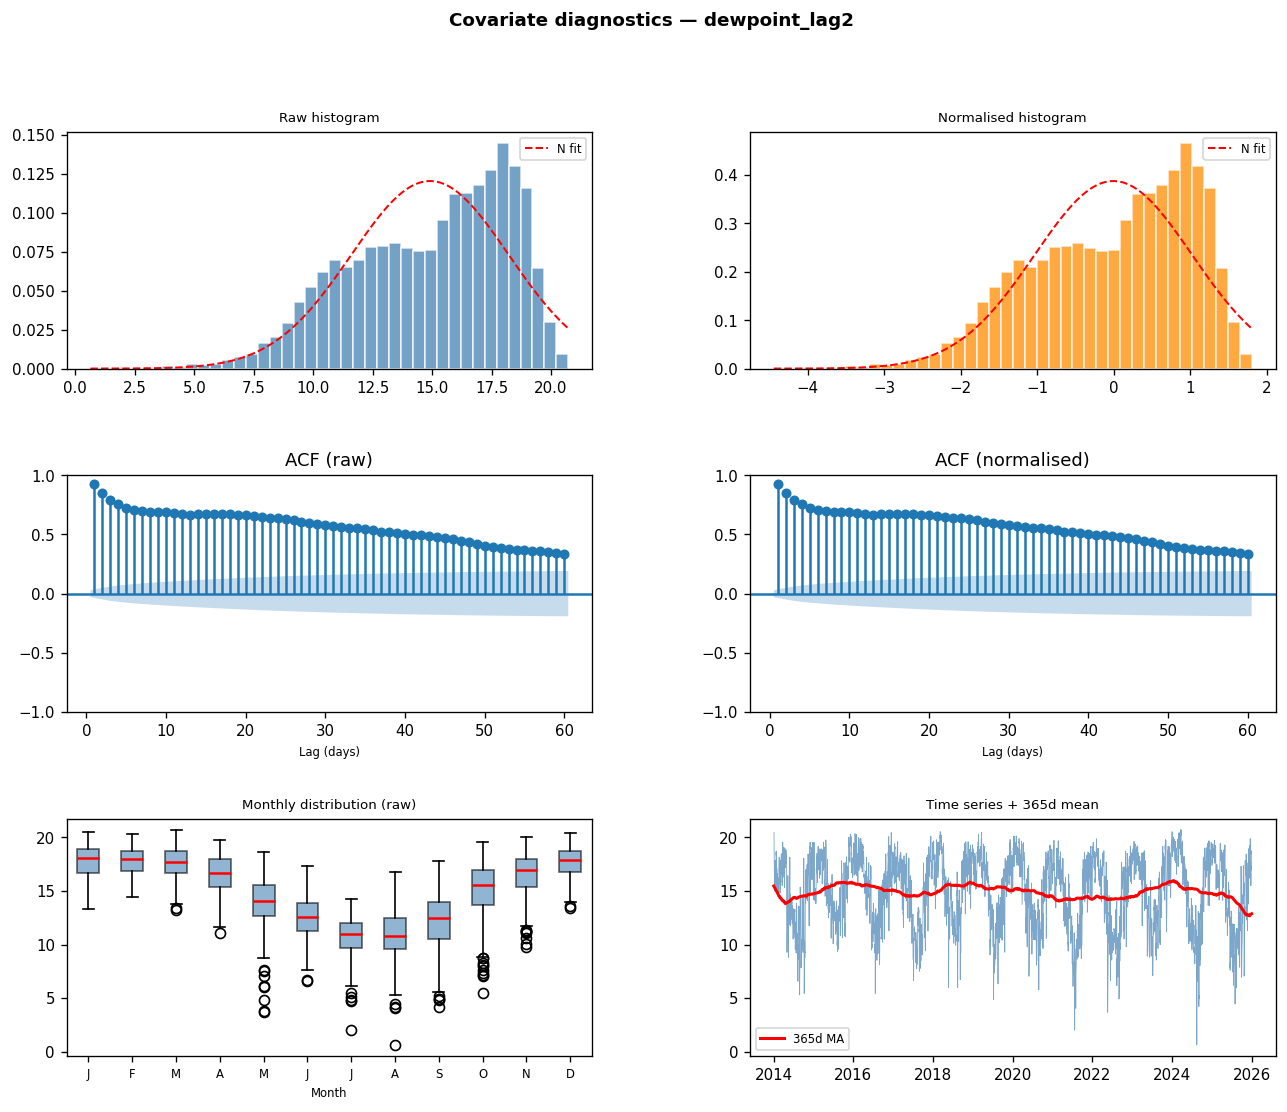

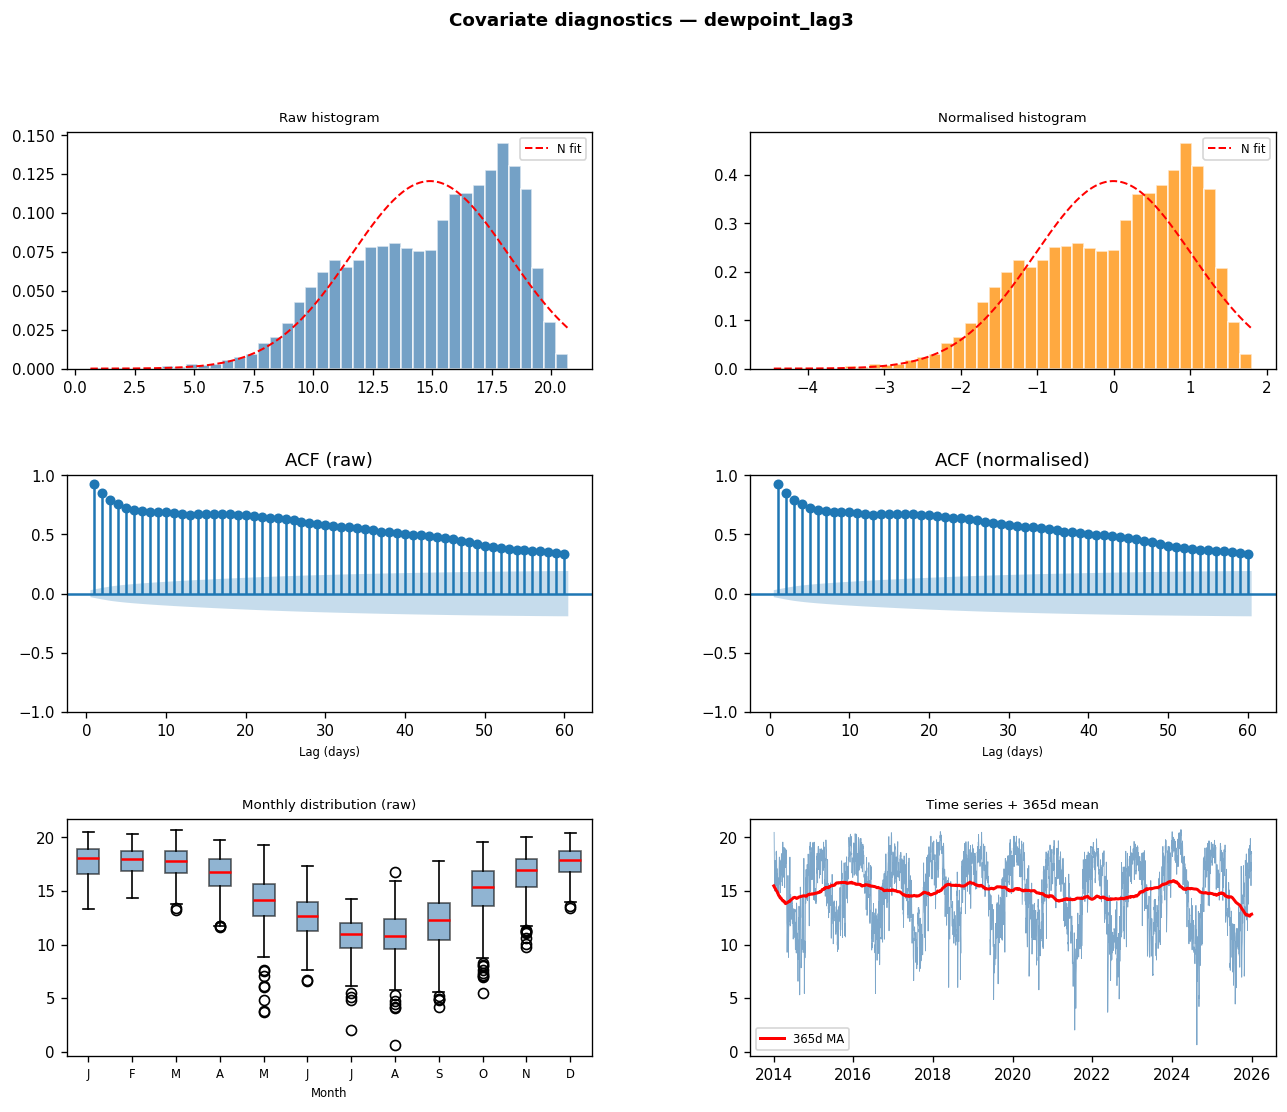

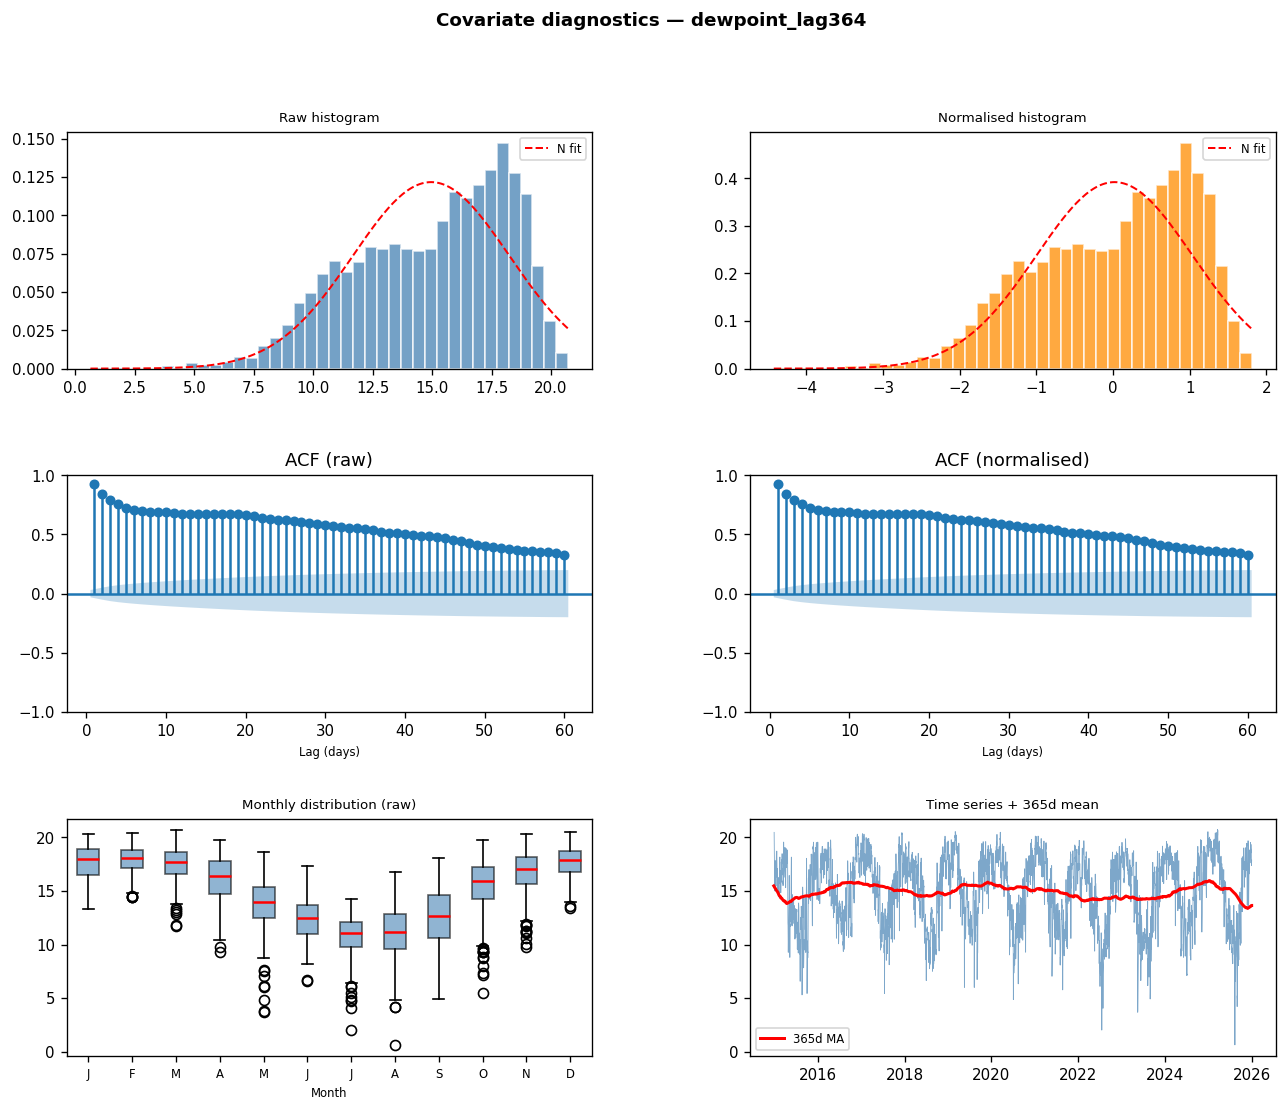

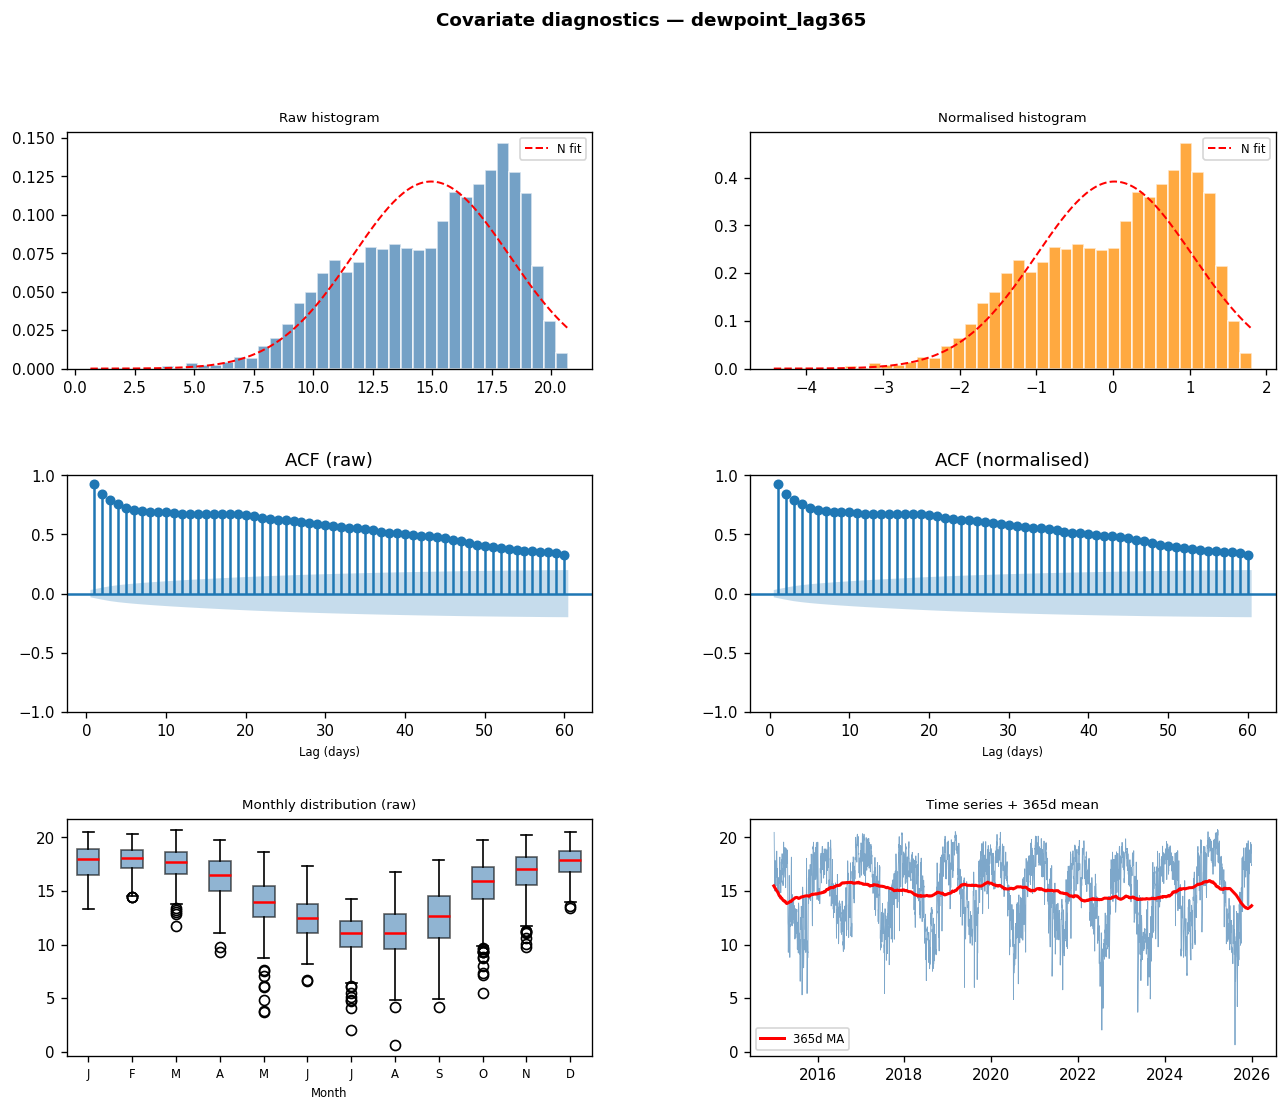

Saved 34 covariate diagnostic figures to C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\artifacts\reports\covariates_long_short\plots_covariates


In [10]:
# ── Per-covariate 6-panel diagnostic figures ─────────────────────────────────
cov_plots_dir = REPORT_DIR / "plots_covariates"
cov_plots_dir.mkdir(parents=True, exist_ok=True)
raw_cols_d = covariate_stats["raw_cols"]
std_cols_d = covariate_stats["std_cols"]

for k, col in enumerate(raw_cols_d):
    if col not in std_cols_d:
        continue
    raw_s = pd.Series(
        raw_cols_d[col].values if hasattr(raw_cols_d[col], "values") else raw_cols_d[col],
        index=all_dates[:len(raw_cols_d[col])],
    )
    std_s = pd.Series(
        std_cols_d[col].values if hasattr(std_cols_d[col], "values") else std_cols_d[col],
        index=all_dates[:len(std_cols_d[col])],
    )
    fig = plot_covariate_page(raw_s, std_s, all_dates, col)
    safe = col.replace("/", "_").replace(" ", "_")
    fig.savefig(cov_plots_dir / f"cov_{safe}.png", dpi=100, bbox_inches="tight")
    if k < 6:   # show first 6 inline
        plt.show()
    else:
        plt.close(fig)

print(f"Saved {len(raw_cols_d)} covariate diagnostic figures to {cov_plots_dir}")


In [11]:
# ── Helper: split standardised block into train / test arrays ─────────────────
def _split_block(bname: str):
    """Return (X_train, X_test) float arrays for a named block."""
    df = std_blocks[bname]
    X_all   = df_to_array(df)
    return X_all[:n_train], X_all[n_train:]


def _block_names(bname: str):
    """Return column names for a standardised block."""
    return list(std_blocks[bname].columns)

---
## Caching Utilities

In [12]:
import os

def _cache_path(model_id: str) -> Path:
    return CACHE_DIR / model_id


def _is_cached(model_id: str) -> bool:
    return (_cache_path(model_id) / "estimated_parameters.csv").exists()


def _save_results_cov(model_id, model, fit_result, paths_is, paths_oos,
                      cdfs_is, cdfs_oos, y_train, y_test,
                      metrics, inf_table, cov):
    """Save all artefacts for a covariate model."""
    d = _cache_path(model_id)
    d.mkdir(parents=True, exist_ok=True)

    model.save_result(fit_result, d)

    # Filtered paths
    np.savez_compressed(d / "filtered_paths_is.npz",
                        f_arr=paths_is["f_arr"],
                        s_arr=paths_is["s_arr"],
                        pi=paths_is["pi"],
                        eta=paths_is["eta"])
    np.savez_compressed(d / "filtered_paths_oos.npz",
                        f_arr=paths_oos["f_arr_oos"],
                        pi=paths_oos["pi_oos"])

    # PIT series
    pd.Series(cdfs_is,  name="cdf_is" ).to_csv(d / "pit_is.csv",  index=False)
    pd.Series(cdfs_oos, name="cdf_oos").to_csv(d / "pit_oos.csv", index=False)

    # Metrics
    for sample, m in [("is", metrics["is"]), ("oos", metrics["oos"])]:
        pd.DataFrame([m]).to_csv(d / f"metrics_{sample}.csv", index=False)

    # Inference
    if inf_table is not None:
        inf_table.to_csv(d / "inference.csv", index=False)
    if cov is not None and np.any(np.isfinite(cov)):
        np.save(d / "covariance_matrix.npy", cov)


def _load_results_cov(model_id):
    """Load cached artefacts for a covariate model."""
    d = _cache_path(model_id)
    theta = pd.read_csv(d / "estimated_parameters.csv")["value"].to_numpy()
    meta  = json.loads((d / "metadata.json").read_text())

    inf_table = None
    if (d / "inference.csv").exists():
        inf_table = pd.read_csv(d / "inference.csv")

    metrics = {}
    for sample in ["is", "oos"]:
        p = d / f"metrics_{sample}.csv"
        if p.exists():
            metrics[sample] = pd.read_csv(p).iloc[0].to_dict()

    return {"theta": theta, "meta": meta, "metrics": metrics,
            "inf_table": inf_table, "loglik": meta.get("loglik", np.nan)}


print("Cache utilities ready.")

Cache utilities ready.


---
## Model Builder Functions

In [13]:
def _build_cov_model(target: str, cov_names: list):
    """
    Build a CovZAGASModel for the given TV-parameter target.

    target : 'xi'    → only xi time-varying
             'phi'   → only phi time-varying
             'phi_xi'→ both phi and xi time-varying
    """
    if target == "xi":
        dist         = GB2LogLinkXiOnly()
        static_params = ["phi", "gamma", "zeta"]
        cov_target    = ["xi"]
    elif target == "phi":
        dist         = GB2LogLinkPhiOnly()
        static_params = ["xi", "gamma", "zeta"]
        cov_target    = ["phi"]
    elif target == "phi_xi":
        dist         = GB2LogLink()
        static_params = ["gamma", "zeta"]
        cov_target    = ["phi", "xi"]
    else:
        raise ValueError(f"Unknown target: {target!r}")

    return CovZAGASModel(
        distribution  = dist,
        pi_dynamics   = ARLogisticPiDynamics(),
        seasonal      = SEASONAL,
        cov_names     = cov_names,
        cov_target    = cov_target,
        static_params = static_params,
    )


def _build_ls_model(ls_target: str, long_names: list, short_names: list):
    """
    Build a LongShortZAGASModel.

    ls_target : 'xi', 'phi', or 'phi_xi'
    """
    if ls_target == "xi":
        dist          = GB2LogLinkXiOnly()
        static_params = ["phi", "gamma", "zeta"]
        target_list   = ["xi"]
    elif ls_target == "phi":
        dist          = GB2LogLinkPhiOnly()
        static_params = ["xi", "gamma", "zeta"]
        target_list   = ["phi"]
    elif ls_target == "phi_xi":
        dist          = GB2LogLink()
        static_params = ["gamma", "zeta"]
        target_list   = ["phi", "xi"]
    else:
        raise ValueError(f"Unknown ls_target: {ls_target!r}")

    return LongShortZAGASModel(
        distribution  = dist,
        pi_dynamics   = ARLogisticPiDynamics(),
        seasonal      = SEASONAL,
        long_names    = long_names,
        short_names   = short_names,
        ls_target     = target_list,
        static_params = static_params,
    )


print("Model builders ready.")

Model builders ready.


---
## Fit-or-Load Helper

In [14]:
from diagnostics.residuals import pit_values, quantile_residuals
from diagnostics.scoring   import compute_all_metrics


def _fit_or_load_cov(
    model_id: str,
    model: CovZAGASModel,
    X_train: np.ndarray,
    X_test:  np.ndarray,
):
    """
    Fit or load a CovZAGASModel.  Returns a results dict.
    """
    if not FORCE_REFIT and _is_cached(model_id):
        print(f"  LOAD  {model_id}")
        cached = _load_results_cov(model_id)
        return cached

    print(f"  FIT   {model_id}  (n_params={model.n_params})")
    fit = model.fit(y_train, X_train, options=OPT_OPTIONS)
    theta = fit["theta"]

    # Filter
    paths_is  = model.filter(theta, y_train, X_train)
    paths_oos = model.simulate_oos(theta, y_train, y_test, X_train, X_test)

    # CDFs
    cdfs_is  = model.cdf_series(theta, y_train, X_train)
    rng = np.random.default_rng(MC_SEED)
    cdfs_oos = np.zeros(len(y_test))
    for i in range(len(y_test)):
        pi_t = paths_oos["pi_oos"][i]
        call = {nm: float(paths_oos["f_arr_oos"][i, j])
                for j, nm in enumerate(paths_oos["tv_names"])}
        call.update(paths_oos["static"])
        if y_test[i] <= 0:
            cdfs_oos[i] = 1.0 - pi_t
        else:
            cdfs_oos[i] = (1.0 - pi_t) + pi_t * model.dist.cdf(y_test[i], **call)

    # Metrics
    metrics = compute_all_metrics(
        model, theta, y_train, y_test,
        paths_is, paths_oos, cdfs_is, cdfs_oos,
        n_draws=N_MC_DRAWS, seed=MC_SEED,
    )

    # Inference
    inf_table = cov_mat = None
    try:
        inf_table, cov_mat, _ = compute_inference(
            model, fit, y_train,
            extra_data={"X": X_train},
            use_numerical_hessian=COMPUTE_NUMERICAL_HESSIAN,
        )
    except Exception as e:
        print(f"    Inference failed: {e}")

    _save_results_cov(model_id, model, fit, paths_is, paths_oos,
                      cdfs_is, cdfs_oos, y_train, y_test,
                      metrics, inf_table, cov_mat)

    return {
        "theta": theta, "loglik": fit["loglik"],
        "metrics": metrics, "inf_table": inf_table,
    }


def _fit_or_load_ls(
    model_id: str,
    model: LongShortZAGASModel,
    X_long_train: np.ndarray,
    X_long_test:  np.ndarray,
    X_short_train: np.ndarray,
    X_short_test:  np.ndarray,
):
    """Fit or load a LongShortZAGASModel."""
    if not FORCE_REFIT and _is_cached(model_id):
        print(f"  LOAD  {model_id}")
        return _load_results_cov(model_id)

    print(f"  FIT   {model_id}  (n_params={model.n_params})")
    fit   = model.fit(y_train, X_long_train, X_short_train, options=OPT_OPTIONS)
    theta = fit["theta"]

    paths_is  = model.filter(theta, y_train, X_long_train, X_short_train)
    paths_oos = model.simulate_oos(
        theta, y_train, y_test,
        X_long_train, X_long_test,
        X_short_train, X_short_test,
    )

    cdfs_is  = model.cdf_series(theta, y_train, X_long_train, X_short_train)
    cdfs_oos = np.zeros(len(y_test))
    for i in range(len(y_test)):
        pi_t = paths_oos["pi_oos"][i]
        call = {nm: float(paths_oos["f_arr_oos"][i, j])
                for j, nm in enumerate(paths_oos["tv_names"])}
        call.update(paths_oos["static"])
        if y_test[i] <= 0:
            cdfs_oos[i] = 1.0 - pi_t
        else:
            cdfs_oos[i] = (1.0 - pi_t) + pi_t * model.dist.cdf(y_test[i], **call)

    metrics = compute_all_metrics(
        model, theta, y_train, y_test,
        paths_is, paths_oos, cdfs_is, cdfs_oos,
        n_draws=N_MC_DRAWS, seed=MC_SEED,
    )

    inf_table = cov_mat = None
    try:
        inf_table, cov_mat, _ = compute_inference(
            model, fit, y_train,
            extra_data={"X_long": X_long_train, "X_short": X_short_train},
            use_numerical_hessian=COMPUTE_NUMERICAL_HESSIAN,
        )
    except Exception as e:
        print(f"    Inference failed: {e}")

    _save_results_cov(model_id, model, fit, paths_is, paths_oos,
                      cdfs_is, cdfs_oos, y_train, y_test,
                      metrics, inf_table, cov_mat)

    return {"theta": theta, "loglik": fit["loglik"],
            "metrics": metrics, "inf_table": inf_table}


print("Fit-or-load helpers ready.")

Fit-or-load helpers ready.


---
## Standard GAS Models with $\xi_t$ Time-Varying

In [15]:
results_all = {}   # {model_id: result_dict}
models_map  = {}   # {model_id: model_object}

XI_BLOCKS = [
    "dewpoint_t", "dewpoint_lag1", "dewpoint_short_lags", "dewpoint_seasonal_lags",
    "temperature_t", "temperature_lag1", "temperature_short_lags", "temperature_seasonal_lags",
    "dewpoint_temperature_t", "dewpoint_temperature_lag1",
    "dewpoint_temperature_short_lags", "dewpoint_temperature_seasonal_lags",
    "mjo_t", "mjo_lag1", "mjo_short_lags",
    "nino34_t", "nino34_lags", "nino34_rolling",
    "interaction_dewpoint_temperature_t", "interaction_dewpoint_mjo",
    "interaction_dewpoint_nino34", "interaction_temperature_nino34",
]

if RUN_XI:
    print("=" * 60)
    print("Standard GAS — xi target")
    print("=" * 60)
    for bname in XI_BLOCKS:
        if bname not in std_blocks:
            continue   # covariate family missing
        model_id = f"xi_{bname}"
        cnames   = _block_names(bname)
        Xtr, Xte = _split_block(bname)
        model    = _build_cov_model("xi", cnames)
        res      = _fit_or_load_cov(model_id, model, Xtr, Xte)
        results_all[model_id] = res
        models_map[model_id]  = model

print(f"\nCompleted xi models: {sum(1 for k in results_all if k.startswith('xi_'))}")

Standard GAS — xi target
  LOAD  xi_dewpoint_t
  LOAD  xi_dewpoint_lag1
  LOAD  xi_dewpoint_short_lags
  LOAD  xi_dewpoint_seasonal_lags
  LOAD  xi_temperature_t
  LOAD  xi_temperature_lag1
  LOAD  xi_temperature_short_lags
  LOAD  xi_temperature_seasonal_lags
  LOAD  xi_dewpoint_temperature_t
  LOAD  xi_dewpoint_temperature_lag1
  LOAD  xi_dewpoint_temperature_short_lags
  LOAD  xi_dewpoint_temperature_seasonal_lags
  LOAD  xi_mjo_t
  LOAD  xi_mjo_lag1
  LOAD  xi_mjo_short_lags
  LOAD  xi_nino34_t
  LOAD  xi_nino34_lags
  LOAD  xi_nino34_rolling
  LOAD  xi_interaction_dewpoint_temperature_t
  LOAD  xi_interaction_dewpoint_mjo
  LOAD  xi_interaction_dewpoint_nino34
  LOAD  xi_interaction_temperature_nino34

Completed xi models: 22


---
## Standard GAS Models with $\phi_t$ Time-Varying

In [16]:
PHI_BLOCKS = XI_BLOCKS  # same covariate ladder

if RUN_PHI:
    print("=" * 60)
    print("Standard GAS — phi target")
    print("=" * 60)
    for bname in PHI_BLOCKS:
        if bname not in std_blocks:
            continue
        model_id = f"phi_{bname}"
        cnames   = _block_names(bname)
        Xtr, Xte = _split_block(bname)
        model    = _build_cov_model("phi", cnames)
        res      = _fit_or_load_cov(model_id, model, Xtr, Xte)
        results_all[model_id] = res
        models_map[model_id]  = model

print(f"\nCompleted phi models: {sum(1 for k in results_all if k.startswith('phi_'))}")

Standard GAS — phi target
  LOAD  phi_dewpoint_t
  LOAD  phi_dewpoint_lag1
  LOAD  phi_dewpoint_short_lags
  LOAD  phi_dewpoint_seasonal_lags
  LOAD  phi_temperature_t
  LOAD  phi_temperature_lag1
  LOAD  phi_temperature_short_lags
  LOAD  phi_temperature_seasonal_lags
  LOAD  phi_dewpoint_temperature_t
  LOAD  phi_dewpoint_temperature_lag1
  LOAD  phi_dewpoint_temperature_short_lags
  LOAD  phi_dewpoint_temperature_seasonal_lags
  LOAD  phi_mjo_t
  LOAD  phi_mjo_lag1
  LOAD  phi_mjo_short_lags
  LOAD  phi_nino34_t


  LOAD  phi_nino34_lags


  LOAD  phi_nino34_rolling
  LOAD  phi_interaction_dewpoint_temperature_t


  LOAD  phi_interaction_dewpoint_mjo
  LOAD  phi_interaction_dewpoint_nino34
  LOAD  phi_interaction_temperature_nino34



Completed phi models: 22

---
## Standard GAS Models with Both $\phi_t$ and $\xi_t$ Time-Varying

In [17]:
PHI_XI_BLOCKS = XI_BLOCKS

if RUN_PHI_XI:
    print("=" * 60)
    print("Standard GAS — phi_xi target")
    print("=" * 60)
    for bname in PHI_XI_BLOCKS:
        if bname not in std_blocks:
            continue
        model_id = f"phi_xi_{bname}"
        cnames   = _block_names(bname)
        Xtr, Xte = _split_block(bname)
        model    = _build_cov_model("phi_xi", cnames)
        res      = _fit_or_load_cov(model_id, model, Xtr, Xte)
        results_all[model_id] = res
        models_map[model_id]  = model

print(f"\nCompleted phi_xi models: {sum(1 for k in results_all if k.startswith('phi_xi_'))}")

Standard GAS — phi_xi target
  LOAD  phi_xi_dewpoint_t
  LOAD  phi_xi_dewpoint_lag1
  LOAD  phi_xi_dewpoint_short_lags
  LOAD  phi_xi_dewpoint_seasonal_lags
  LOAD  phi_xi_temperature_t
  LOAD  phi_xi_temperature_lag1
  LOAD  phi_xi_temperature_short_lags
  LOAD  phi_xi_temperature_seasonal_lags
  LOAD  phi_xi_dewpoint_temperature_t
  LOAD  phi_xi_dewpoint_temperature_lag1
  LOAD  phi_xi_dewpoint_temperature_short_lags
  LOAD  phi_xi_dewpoint_temperature_seasonal_lags
  LOAD  phi_xi_mjo_t
  FIT   phi_xi_mjo_lag1  (n_params=31)


  FIT   phi_xi_mjo_short_lags  (n_params=39)


  FIT   phi_xi_nino34_t  (n_params=25)


  FIT   phi_xi_nino34_lags  (n_params=29)


  FIT   phi_xi_nino34_rolling  (n_params=29)


  FIT   phi_xi_interaction_dewpoint_temperature_t  (n_params=25)


  FIT   phi_xi_interaction_dewpoint_mjo  (n_params=27)


  FIT   phi_xi_interaction_dewpoint_nino34  (n_params=25)


  FIT   phi_xi_interaction_temperature_nino34  (n_params=25)



Completed phi_xi models: 22


---
## Long-Short Models

The long-short block specifications:

| Variant | $L_t$ (long) | $S_t$ (short) |
|---------|--------------|---------------|
| `basic` | $N34_t$ | $D_t, T_t, RMM1_t, RMM2_t$ |
| `short_lags` | $N34_t$ | $D_{t..t-3}, T_{t..t-3}, RMM_{t..t-3}$ |
| `weather_climate` | $N34_t, \overline{N34}_{30}, \overline{N34}_{90}$ | short lags |
| `interactions` | $N34_t$ | short + $D\times T, D\times RMM1, D\times RMM2$ |

In [18]:
# ── Build long and short matrices ─────────────────────────────────────────────

def _long_array(variant: str):
    """Standardised N34 long-component matrix for the given variant."""
    if "nino34_t" not in std_blocks and "nino34_rolling" not in std_blocks:
        return None, None, []
    if variant in ["basic", "short_lags", "interactions"]:
        bname = "nino34_t"
    else:  # weather_climate
        bname = "nino34_rolling"
    if bname not in std_blocks:
        bname = "nino34_t"  # fallback
    if bname not in std_blocks:
        return None, None, []
    Xtr, Xte = _split_block(bname)
    return Xtr, Xte, _block_names(bname)


def _short_array(variant: str):
    """Standardised short-component matrix for the given variant."""
    frames_train = []
    frames_test  = []
    names        = []

    def _add(bname):
        if bname in std_blocks:
            Xtr, Xte = _split_block(bname)
            frames_train.append(Xtr)
            frames_test.append(Xte)
            names.extend(_block_names(bname))

    if variant == "basic":
        for b in ["dewpoint_t", "temperature_t", "mjo_t"]:
            _add(b)
    elif variant in ["short_lags", "weather_climate"]:
        for b in ["dewpoint_short_lags", "temperature_short_lags", "mjo_short_lags"]:
            _add(b)
    elif variant == "interactions":
        for b in ["dewpoint_short_lags", "temperature_short_lags", "mjo_short_lags",
                  "interaction_dewpoint_temperature_t",
                  "interaction_dewpoint_mjo"]:
            _add(b)

    if not frames_train:
        return None, None, []

    # De-duplicate column names
    seen = set()
    keep = []
    for i, n in enumerate(names):
        if n not in seen:
            seen.add(n)
            keep.append(i)

    Xtr = np.hstack(frames_train)[:, keep]
    Xte = np.hstack(frames_test )[:, keep]
    return Xtr, Xte, [names[i] for i in keep]


LS_VARIANTS = ["basic", "short_lags", "weather_climate", "interactions"]
print("Long-short array builders ready.")

Long-short array builders ready.


### Long-Short $\xi_t$ models

In [19]:
if RUN_LS_XI:
    print("=" * 60)
    print("Long-Short — xi target")
    print("=" * 60)
    for variant in LS_VARIANTS:
        Xlt, Xlte, long_names  = _long_array(variant)
        Xst, Xste, short_names = _short_array(variant)
        if Xlt is None or Xst is None:
            print(f"  SKIP  long_short_xi_{variant}  (missing covariates)")
            continue
        model_id = f"long_short_xi_{variant}"
        model    = _build_ls_model("xi", long_names, short_names)
        res      = _fit_or_load_ls(model_id, model,
                                   Xlt, Xlte, Xst, Xste)
        results_all[model_id] = res
        models_map[model_id]  = model

print(f"\nCompleted long_short_xi models: {sum(1 for k in results_all if 'long_short_xi' in k)}")

Long-Short — xi target
  FIT   long_short_xi_basic  (n_params=23)


  FIT   long_short_xi_short_lags  (n_params=35)


  FIT   long_short_xi_weather_climate  (n_params=37)


  FIT   long_short_xi_interactions  (n_params=38)



Completed long_short_xi models: 4


### Long-Short $\phi_t$ models

In [20]:
if RUN_LS_PHI:
    print("=" * 60)
    print("Long-Short — phi target")
    print("=" * 60)
    for variant in LS_VARIANTS:
        Xlt, Xlte, long_names  = _long_array(variant)
        Xst, Xste, short_names = _short_array(variant)
        if Xlt is None or Xst is None:
            print(f"  SKIP  long_short_phi_{variant}  (missing covariates)")
            continue
        model_id = f"long_short_phi_{variant}"
        model    = _build_ls_model("phi", long_names, short_names)
        res      = _fit_or_load_ls(model_id, model,
                                   Xlt, Xlte, Xst, Xste)
        results_all[model_id] = res
        models_map[model_id]  = model

print(f"\nCompleted long_short_phi models: {sum(1 for k in results_all if 'long_short_phi_' in k)}")

Long-Short — phi target
  FIT   long_short_phi_basic  (n_params=23)


  FIT   long_short_phi_short_lags  (n_params=35)


  FIT   long_short_phi_weather_climate  (n_params=37)


  FIT   long_short_phi_interactions  (n_params=38)



Completed long_short_phi models: 4


### Long-Short $\phi_t, \xi_t$ models

In [21]:
if RUN_LS_PHI_XI:
    print("=" * 60)
    print("Long-Short — phi_xi target")
    print("=" * 60)
    for variant in LS_VARIANTS:
        Xlt, Xlte, long_names  = _long_array(variant)
        Xst, Xste, short_names = _short_array(variant)
        if Xlt is None or Xst is None:
            print(f"  SKIP  long_short_phi_xi_{variant}  (missing covariates)")
            continue
        model_id = f"long_short_phi_xi_{variant}"
        model    = _build_ls_model("phi_xi", long_names, short_names)
        res      = _fit_or_load_ls(model_id, model,
                                   Xlt, Xlte, Xst, Xste)
        results_all[model_id] = res
        models_map[model_id]  = model

print(f"\nCompleted long_short_phi_xi models: {sum(1 for k in results_all if 'long_short_phi_xi' in k)}")

Long-Short — phi_xi target
  FIT   long_short_phi_xi_basic  (n_params=37)


  FIT   long_short_phi_xi_short_lags  (n_params=61)


  FIT   long_short_phi_xi_weather_climate  (n_params=65)


  FIT   long_short_phi_xi_interactions  (n_params=67)



Completed long_short_phi_xi models: 4


---
## Diagnostics

In [22]:
# ── Summary diagnostics for every completed model ─────────────────────────────
diag_by_model = {}

for model_id, res in results_all.items():
    d = _cache_path(model_id)
    diag = {}

    # Reload filtered paths if cached
    is_npz  = d / "filtered_paths_is.npz"
    oos_npz = d / "filtered_paths_oos.npz"
    if is_npz.exists():
        npz = np.load(is_npz)
        diag["is_paths"] = {
            "f_arr": npz["f_arr"], "pi": npz["pi"], "eta": npz["eta"],
            "tv_names": json.loads((d / "metadata.json").read_text()).get("tv_names", []),
            "static": {},
        }
    if oos_npz.exists():
        npz = np.load(oos_npz)
        diag["oos_paths"] = {
            "f_arr_oos": npz["f_arr"], "pi_oos": npz["pi"],
            "tv_names": json.loads((d / "metadata.json").read_text()).get("tv_names", []),
            "static": {},
        }

    # PIT / QR from cached CDFs
    pit_is_path  = d / "pit_is.csv"
    pit_oos_path = d / "pit_oos.csv"
    if pit_is_path.exists():
        cdfs_is  = pd.read_csv(pit_is_path)["cdf_is"].to_numpy()
        eff = len(y_train) - len(cdfs_is)
        y_eff = y_train[eff:]
        diag["is_pit"] = pit_values(cdfs_is, y_eff)
        diag["is_qr"]  = quantile_residuals(cdfs_is, y_eff)
    if pit_oos_path.exists():
        cdfs_oos  = pd.read_csv(pit_oos_path)["cdf_oos"].to_numpy()
        diag["oos_pit"] = pit_values(cdfs_oos, y_test)
        diag["oos_qr"]  = quantile_residuals(cdfs_oos, y_test)

    diag_by_model[model_id] = diag

print(f"Diagnostics loaded for {len(diag_by_model)} models.")

Diagnostics loaded for 78 models.


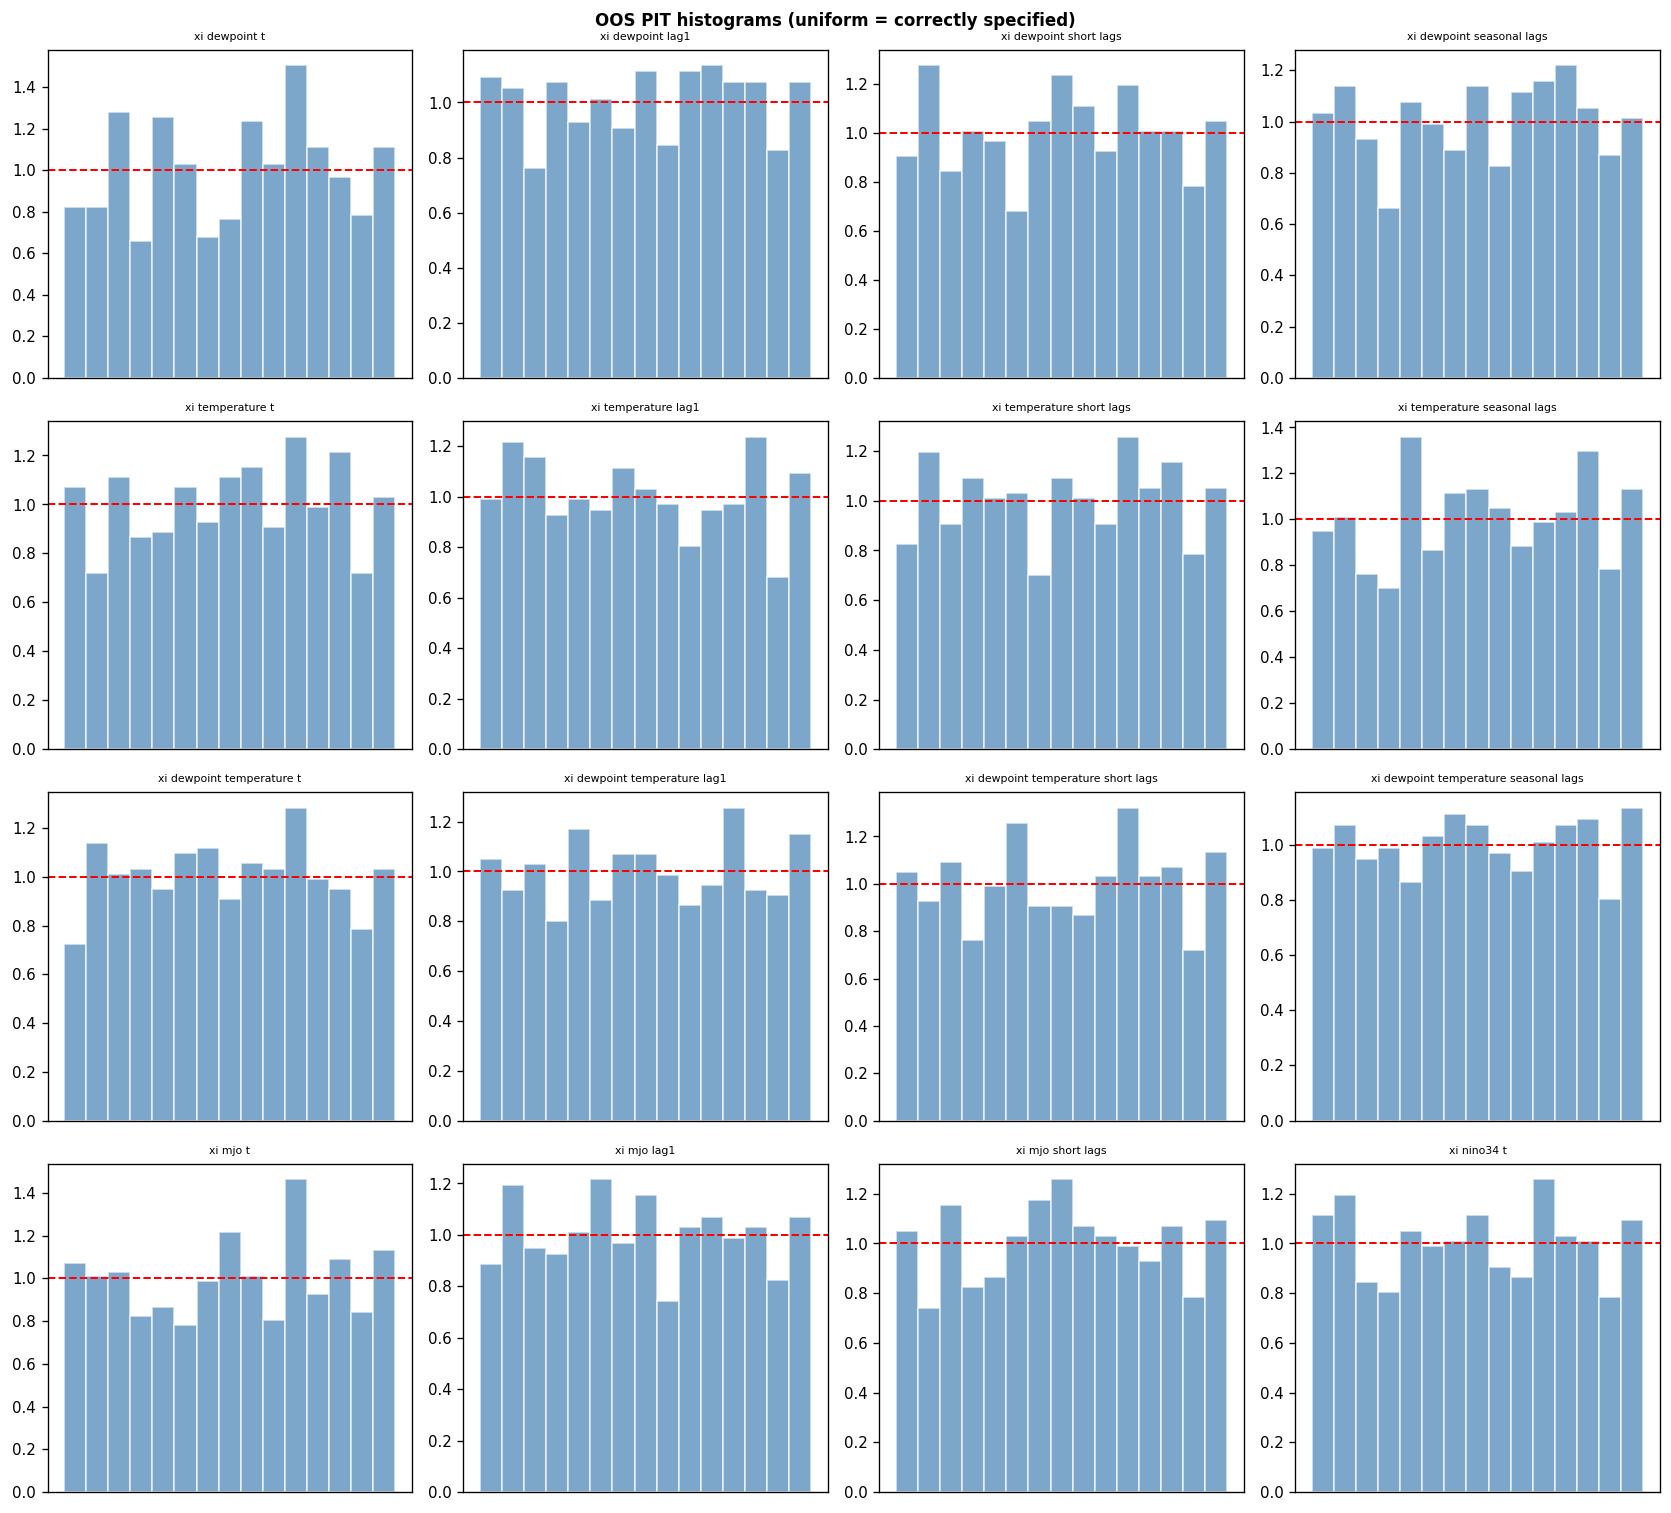

In [23]:
# ── Quick PIT histograms grid ─────────────────────────────────────────────────
pit_models = [mid for mid, d in diag_by_model.items() if "oos_pit" in d]
n_pit = min(len(pit_models), 16)
if n_pit > 0:
    ncols = 4
    nrows = (n_pit + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
    axes = np.array(axes).flatten()
    for k, mid in enumerate(pit_models[:n_pit]):
        ax = axes[k]
        u  = diag_by_model[mid]["oos_pit"]
        ax.hist(u, bins=15, density=True, color="steelblue", alpha=0.7, edgecolor="w")
        ax.axhline(1.0, color="r", lw=1.2, ls="--")
        ax.set_title(mid.replace("_", " "), fontsize=6.5)
        ax.set_xticks([])
    for k in range(n_pit, len(axes)):
        axes[k].axis("off")
    fig.suptitle("OOS PIT histograms (uniform = correctly specified)",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    fig.savefig(REPORT_DIR / "oos_pit_grid.png", dpi=120, bbox_inches="tight")
    REPORT_DIR.mkdir(parents=True, exist_ok=True)
    plt.show()

---
## Model Comparison

In [24]:
# ── Compile metrics table ─────────────────────────────────────────────────────
from diagnostics.scoring import metrics_to_frame, latex_metrics_table

metrics_by_model_full = {mid: res["metrics"] for mid, res in results_all.items()
                         if "metrics" in res}
inf_by_model_full     = {mid: res.get("inf_table") for mid, res in results_all.items()}

oos_frame = metrics_to_frame(metrics_by_model_full, sample="oos")
is_frame  = metrics_to_frame(metrics_by_model_full, sample="is")

REPORT_DIR.mkdir(parents=True, exist_ok=True)
oos_frame.to_csv(REPORT_DIR / "comparison_oos.csv", index=False)
is_frame.to_csv( REPORT_DIR / "comparison_is.csv",  index=False)

# Display top-10 by OOS CRPS
if "crps" in oos_frame.columns:
    top10 = oos_frame.sort_values("crps").head(10)
    display_cols = [c for c in ["model_id", "loglik", "aic", "bic", "crps",
                                 "rmse", "mad", "kup95_pvalue"] if c in top10.columns]
    print("Top 10 models by OOS CRPS:")
    print(top10[display_cols].to_string(index=False))

Top 10 models by OOS CRPS:
                                 model_id       loglik         aic         bic     crps       rmse        mad  kup95_pvalue
phi_xi_dewpoint_temperature_seasonal_lags -1131.932786 2373.865572 2626.558312 2.447595  34.320109  19.626282      0.365791
             long_short_phi_xi_short_lags -1124.312389 2370.624778 2650.883999 2.462157 480.091026 297.406419      0.365791
         phi_xi_dewpoint_temperature_lag1 -1140.854746 2343.709493 2486.136310 2.497041  52.445568  32.027336      0.365791
                     phi_xi_temperature_t -1167.980344 2385.960688 2500.821025 2.510695 705.214889 493.172766      0.365791
            phi_xi_dewpoint_seasonal_lags -1127.157239 2332.314477 2511.496602 2.545311  10.227179   4.936977      0.680708
           long_short_phi_xi_interactions -1123.362985 2380.725970 2688.551671 2.548630  27.014998  15.984111      0.365791
               phi_dewpoint_seasonal_lags -1123.327957 2294.655914 2404.921837 2.548679  19.801439  11.89

In [25]:
# ── Save LaTeX tables ─────────────────────────────────────────────────────────
from diagnostics.scoring import latex_metrics_table

tex_oos = latex_metrics_table(
    oos_frame,
    caption="Out-of-sample model comparison",
    label="tab:oos_comparison",
    landscape=True,
)
(REPORT_DIR / "table_oos_metrics.tex").write_text(tex_oos, encoding="utf-8")

tex_is = latex_metrics_table(
    is_frame,
    caption="In-sample model comparison",
    label="tab:is_comparison",
    landscape=True,
)
(REPORT_DIR / "table_is_metrics.tex").write_text(tex_is, encoding="utf-8")

print(f"LaTeX tables saved to {REPORT_DIR}")

LaTeX tables saved to C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\artifacts\reports\covariates_long_short


In [26]:
# ── Save inference tables ─────────────────────────────────────────────────────
from models.inference import latex_inference_table

for mid, inf in inf_by_model_full.items():
    if inf is None or inf.empty:
        continue
    cov_df = inf[
        inf["parameter"].str.startswith("gamma")
        | inf["parameter"].str.startswith("alpha_L")
        | inf["parameter"].str.startswith("beta_L")
        | inf["parameter"].str.startswith("gamma_S")
    ].copy()
    if cov_df.empty:
        cov_df = inf.copy()
    tex = latex_inference_table(
        cov_df,
        caption=f"Parameter inference — {mid}",
        label=f"tab:inf_{mid}",
    )
    (REPORT_DIR / f"inference_{mid}.tex").write_text(tex, encoding="utf-8")

print("Individual inference tables saved.")

Individual inference tables saved.


---
## Report Generation

Generates `artifacts/reports/covariates_long_short/report.pdf` and
`report.tex`.

### To regenerate the PDF from edited LaTeX without re-running models:

1. Edit `artifacts/reports/covariates_long_short/report.tex` in any text editor.
2. Run **one** of these in the cell below:
   - `recompile_pdf_from_latex(tex_path)` — uses `pdflatex` if installed.
   - Or: open `report.tex` in Overleaf / any LaTeX editor and compile there.
3. The PDF and LaTeX are fully independent of the notebook after generation.

In [27]:
from report.cov_report import render_covariate_report, recompile_pdf_from_latex

ts = datetime.now().strftime("%Y-%m-%d %H:%M")

report_paths = render_covariate_report(
    report_dir         = REPORT_DIR,
    station            = STATION,
    metrics_by_model   = metrics_by_model_full,
    diag_by_model      = diag_by_model,
    inf_by_model       = inf_by_model_full,
    is_dates           = train_dates,
    oos_dates          = test_dates,
    timestamp          = ts,
    covariate_stats    = covariate_stats,
    cache_dir          = CACHE_DIR,
    all_dates          = all_dates,
)

print(f"PDF  → {report_paths['pdf_path']}")
print(f"LaTeX→ {report_paths['tex_path']}")

PDF  → C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\artifacts\reports\covariates_long_short\report.pdf
LaTeX→ C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\artifacts\reports\covariates_long_short\report.tex


In [28]:
# ── Recompile PDF from LaTeX (run this cell after editing report.tex) ─────────
# Uncomment if pdflatex is installed:
# success = recompile_pdf_from_latex(report_paths["tex_path"])
# print("Recompile:", "OK" if success else "FAILED (see instructions above)")

---
## Running from Saved Models

Everything needed to reproduce or extend results is saved under
`artifacts/cache_covariates_long_short/<model_id>/`.

### What is saved per model

| File | Contents |
|------|----------|
| `estimated_parameters.csv` | `name`, `value` — the MLE vector |
| `metadata.json` | loglik, AIC, BIC, n_params, tv_names, cov_names, timestamp |
| `gradients.csv` | gradient at optimum (should be near zero) |
| `hess_inv.npy` | BFGS inverse Hessian approximation |
| `filtered_paths_is.npz` | in-sample f_arr, s_arr, pi, eta |
| `filtered_paths_oos.npz` | OOS f_arr, pi |
| `pit_is.csv` / `pit_oos.csv` | CDF values for PIT construction |
| `metrics_is.csv` / `metrics_oos.csv` | all scalar metrics |
| `inference.csv` | parameter table with SE, z, p, CI |
| `covariance_matrix.npy` | asymptotic covariance matrix |

### How to run from saved models without refitting

**Option A — run the full notebook with `FORCE_REFIT = False`** (default).  
All fitting cells will print `LOAD <model_id>` instead of optimising.  
The diagnostics, comparison, and report cells run normally.

**Option B — load a single model manually** (code cell below).  
Useful when you want to inspect one model, plot a custom diagnostic,
or add a new metric without touching the others.

### Minimal re-run to regenerate only the report

After all models are cached, run **only** these cells in order:

1. **Configuration** — sets paths and flags
2. **Imports**
3. **Data Loading** — loads y_train, y_test, dates
4. **Covariate Construction** (all four cells) — rebuilds std_blocks
5. **Caching Utilities**
6. **Model Builder Functions**
7. **Diagnostics** — reloads PIT / paths from .npz / .csv (no fitting)
8. **Model Comparison** — rebuilds tables from metrics_*.csv
9. **Report Generation** — writes new PDF + LaTeX

Or to only edit the report text: edit `artifacts/reports/covariates_long_short/report.tex`
and recompile with `recompile_pdf_from_latex()` (or Overleaf).


Model:    xi_dewpoint_t
loglik:   -5075.3824
AIC: n/a
BIC: n/a
n_params: 17

          parameter     value
           omega_xi  0.505608
              f0_xi  0.166224
             A_xi_1  0.044044
           A_xi_365  0.149298
           A_xi_366  0.113811
             B_xi_1 -0.171383
           B_xi_365 -0.305267
           B_xi_366  0.191524
                phi 19.712495
              gamma  0.619424
               zeta  9.991810
             omega0 -1.103003
                rho  0.297358
          omega_y_1  0.068042
        omega_y_365  0.013078
        omega_y_366  0.014697
gamma_xi_dewpoint_t  0.353546


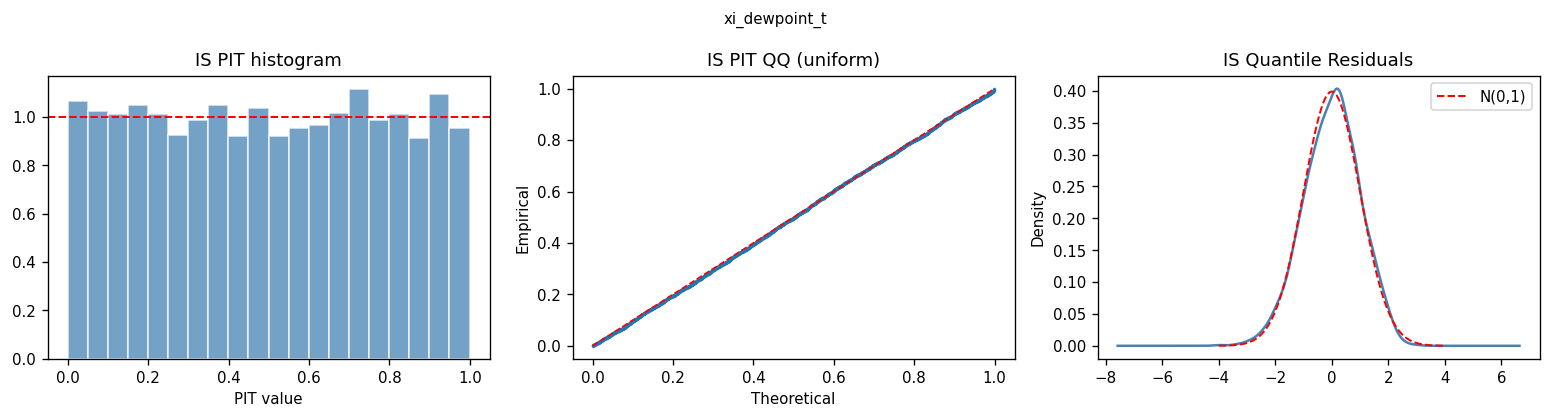


Inference table:


,parameter,estimate,SE,z_stat,p_value,ci_lower,ci_upper,sig_10pct,sig_5pct,sig_1pct,se_reliable
0,omega_xi,0.5056,NaN,NaN,NaN,NaN,NaN,False,False,False,False
1,f0_xi,0.1662,0.7205,0.2307,0.8175,-1.2459,1.5784,False,False,False,False
2,A_xi_1,0.0440,0.0451,0.9770,0.3286,-0.0443,0.1324,False,False,False,False
3,A_xi_365,0.1493,0.0500,2.9861,0.0028,0.0513,0.2473,True,True,True,False
4,A_xi_366,0.1138,0.0374,3.0441,0.0023,0.0405,0.1871,True,True,True,False
5,B_xi_1,-0.1714,NaN,NaN,NaN,NaN,NaN,False,False,False,False
6,B_xi_365,-0.3053,0.0310,-9.8407,0.0000,-0.3661,-0.2445,True,True,True,False
7,B_xi_366,0.1915,NaN,NaN,NaN,NaN,NaN,False,False,False,False
8,phi,19.7125,NaN,NaN,NaN,NaN,NaN,False,False,False,False
9,gamma,0.6194,NaN,NaN,NaN,NaN,NaN,False,False,False,False


In [29]:
# ── Load a single model from cache and inspect without refitting ──────────────
# Set MODEL_ID to whichever model you want to examine.
# Requires that the preceding cells (config -> covariate construction ->
# caching utilities) have already been run in this session.

MODEL_ID = "xi_dewpoint_t"   # <-- change this to any model_id

d = _cache_path(MODEL_ID)
if not d.exists():
    print(f"Cache not found: {d}")
else:
    theta_df = pd.read_csv(d / "estimated_parameters.csv")
    theta    = theta_df["value"].to_numpy()
    meta     = json.loads((d / "metadata.json").read_text())
    print(f"Model:    {MODEL_ID}")
    ll  = meta.get("loglik")
    aic = meta.get("aic")
    bic = meta.get("bic")
    print(f"loglik:   {ll:.4f}"   if ll  is not None else "loglik: n/a")
    print(f"AIC:      {aic:.2f}"  if aic is not None else "AIC: n/a")
    print(f"BIC:      {bic:.2f}"  if bic is not None else "BIC: n/a")
    print(f"n_params: {meta.get('n_params','n/a')}")
    print()
    print(theta_df.to_string(index=False))

    # Reload IS PIT and plot
    pit_path = d / "pit_is.csv"
    if pit_path.exists():
        cdfs_is = pd.read_csv(pit_path)["cdf_is"].to_numpy()
        eff     = len(y_train) - len(cdfs_is)
        y_eff   = y_train[eff:]
        u_is    = pit_values(cdfs_is, y_eff)

        from scipy import stats as _stats
        fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

        axes[0].hist(u_is, bins=20, density=True,
                     color="steelblue", alpha=0.75, edgecolor="w")
        axes[0].axhline(1.0, color="r", lw=1.2, ls="--")
        axes[0].set_title(f"IS PIT histogram")
        axes[0].set_xlabel("PIT value")

        n_u    = len(u_is)
        q_emp  = np.sort(u_is)
        q_unif = (np.arange(1, n_u + 1) - 0.5) / n_u
        axes[1].plot(q_unif, q_emp, ".", ms=2, alpha=0.5)
        axes[1].plot([0, 1], [0, 1], "r--", lw=1)
        axes[1].set_title("IS PIT QQ (uniform)")
        axes[1].set_xlabel("Theoretical")
        axes[1].set_ylabel("Empirical")

        qr_is     = quantile_residuals(cdfs_is, y_eff)
        finite_qr = qr_is[np.isfinite(qr_is)]
        pd.Series(finite_qr).plot(kind="kde", ax=axes[2], color="steelblue")
        xgrid = np.linspace(-4, 4, 200)
        axes[2].plot(xgrid, _stats.norm.pdf(xgrid), "r--", lw=1.2, label="N(0,1)")
        axes[2].set_title("IS Quantile Residuals")
        axes[2].legend()
        plt.suptitle(MODEL_ID, fontsize=9)
        plt.tight_layout()
        plt.show()

    # Inference table
    inf_path = d / "inference.csv"
    if inf_path.exists():
        print("\nInference table:")
        display(pd.read_csv(inf_path).round(4))


---
## Final Recommendations

In [30]:
from report.cov_report import _auto_discussion, _auto_conclusion

print("=" * 70)
print("DISCUSSION")
print("=" * 70)
print(_auto_discussion(metrics_by_model_full, inf_by_model_full))
print()
print("=" * 70)
print("CONCLUSION")
print("=" * 70)
print(_auto_conclusion(metrics_by_model_full))

DISCUSSION
By OOS CRPS, the best-performing model is 'phi_xi_dewpoint_temperature_seasonal_lags' (CRPS = 2.4476) and the worst is 'xi_mjo_t' (CRPS = 2.7796). The lowest IS AIC belongs to 'phi_dewpoint_temperature_t' (AIC = 2278.8205). No model fails the Kupiec 95\% coverage test. Best tail-weighted CRPS (90% threshold): 'long_short_phi_interactions' (0.3562). Best tail-weighted CRPS (95% threshold): 'long_short_phi_interactions' (0.2619). Models with at least one covariate coefficient significant at 5\%: 'xi_dewpoint_lag1': gamma, gamma_xi_dewpoint_t, gamma_xi_dewpoint_lag1; 'xi_dewpoint_short_lags': gamma, gamma_xi_dewpoint_t, gamma_xi_dewpoint_lag1, gamma_xi_dewpoint_lag2; 'xi_dewpoint_seasonal_lags': gamma_xi_dewpoint_t, gamma_xi_dewpoint_lag1; 'xi_temperature_t': gamma, gamma_xi_temperature_t; 'xi_temperature_lag1': gamma, gamma_xi_temperature_lag1; 'xi_temperature_short_lags': gamma, gamma_xi_temperature_t, gamma_xi_temperature_lag1, gamma_xi_temperature_lag2.

CONCLUSION
Based on